In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Image, Markdown, display

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from data.share_data import load_share_data
from scripts.mpc import plot_mpc_outputs, run_admm_mpc_ev, run_local_mpc_ev
from utils.records import compute_ev_agent_cost_summary, compute_ev_cost_summary
from utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/madrl_traindays_7")
cfg, run_dir = load_experiment_context(run_dir)

cfg.env.ev_enabled = True
cfg.model.action_dim = 3
cfg.env.ev_departure_constraint_mode = "soft"
cfg.env.ev_hard_projection_enabled = False
cfg.env.ev_emergency_charging_enabled = False
cfg.env.ev_emergency_window_hours = float(cfg.env.ev_emergency_window_hours)
cfg.env.ev_emergency_strategy = "required_power"

cfg.env.ev_capacity_kwh = (60.0, 60.0, 60.0)
cfg.env.ev_soc_min = 0.10
cfg.env.ev_soc_max = 0.95
cfg.env.ev_arrival_soc = 0.3
cfg.env.ev_departure_soc_req = 0.90
cfg.env.ev_max_charge_kw = (11.0, 11.0, 11.0)
cfg.env.ev_efficiency = 0.95
cfg.env.ev_arrival_step = 72
cfg.env.ev_departure_step = 28
cfg.reward.ev_departure_penalty_weight = 1000.0
cfg.reward.ev_soc_regularization_weight = 0.005
cfg.reward.ev_projection_penalty_weight = 0.0
cfg.reward.ev_emergency_penalty_weight = 0.0

share_data = load_share_data(run_dir / "share_data", cfg)
train_episodes = 1000 
display(Markdown("# MPC + EV Soft Constraint"))
display(pd.DataFrame([{
    "run_dir": str(run_dir),
    "eval_start": cfg.data.eval_start_date,
    "eval_end": cfg.data.eval_end_date,
    "eval_episodes": int(share_data.eval["price"].shape[0]),
    "ev_enabled": bool(cfg.env.ev_enabled),
    "action_dim": int(cfg.model.action_dim),
    "ev_constraint_mode": cfg.env.ev_departure_constraint_mode,
    "ev_capacity_kwh": cfg.env.ev_capacity_kwh,
    "ev_arrival_soc": float(cfg.env.ev_arrival_soc),
    "ev_departure_soc_req": float(cfg.env.ev_departure_soc_req),
    "ev_max_charge_kw": cfg.env.ev_max_charge_kw,
    "ev_arrival_step": int(cfg.env.ev_arrival_step),
    "ev_departure_step": int(cfg.env.ev_departure_step),
    "ev_departure_penalty_weight": float(cfg.reward.ev_departure_penalty_weight),
    "ev_hard_projection_enabled": bool(cfg.env.ev_hard_projection_enabled),
    "ev_emergency_charging_enabled": bool(cfg.env.ev_emergency_charging_enabled),
    "ev_emergency_window_hours": float(cfg.env.ev_emergency_window_hours),
}]))


# MPC + EV Soft Constraint

,run_dir,eval_start,eval_end,eval_episodes,ev_enabled,action_dim,ev_constraint_mode,ev_capacity_kwh,ev_arrival_soc,ev_departure_soc_req,ev_max_charge_kw,ev_arrival_step,ev_departure_step,ev_departure_penalty_weight,ev_hard_projection_enabled,ev_emergency_charging_enabled,ev_emergency_window_hours
0,artifacts\runs\madrl_traindays_7,2020-04-01,2020-04-15,15,True,3,soft,"(60.0, 60.0, 60.0)",0.3,0.9,"(11.0, 11.0, 11.0)",72,28,1000.0,False,False,1.0


In [3]:
local_records = run_local_mpc_ev(cfg, run_dir, share_data, ev_mode=cfg.env.ev_departure_constraint_mode)
admm_record = run_admm_mpc_ev(cfg, run_dir, share_data, ev_mode=cfg.env.ev_departure_constraint_mode)
records = {"local": local_records, "admm": admm_record}
metrics_df = pd.concat([local_records["perfect"]["metrics_df"], local_records["lstm"]["metrics_df"], admm_record["metrics_df"]], ignore_index=True)
display(Markdown("## Metrics"))
display(metrics_df)
pprint({"record_root": str(run_dir / "results")})


local MPC EV soft modes:   0%|          | 0/2 [00:00<?, ?mode/s]

Local MPC + Perfect Forecast + EV Soft Constraint/perfect:   0%|          | 0/15 [00:00<?, ?episode/s]

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2830634
Academic license 2830634 - for non-commercial use only - registered to we___@163.com


Local MPC + LSTM Forecast + EV Soft Constraint/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

ADMM MPC + LSTM Forecast + EV Soft Constraint/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

## Metrics

,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Local MPC + Perfect Forecast + EV Soft Constraint,continuous,895.894662,1475.392146,579.497484,-579.497484,211.154333,-368.343156,3.512965,0.000077,...,0.019578,0.076885,0.005727,0.039214,165,178.589813,33.696671,368.391052,44.052921,-579.497489
1,Local MPC + LSTM Forecast + EV Soft Constraint,continuous,433.195292,724.772357,291.577065,-291.577065,208.322979,-83.254091,0.007027,0.000023,...,0.016508,0.049562,0.005099,0.039214,108,168.475708,27.656233,183.602737,28.537500,-291.577070
2,ADMM MPC + LSTM Forecast + EV Soft Constraint,continuous,437.761688,673.309262,235.547574,-235.547574,210.692745,-24.854828,8.715298,0.000000,...,0.010928,0.047511,0.004793,0.039606,0,97.748711,21.383484,116.360771,27.489106,-235.547573


{'record_root': 'artifacts\\runs\\madrl_traindays_7\\results'}


In [4]:
display(Markdown("## EV and total cost summary"))
rollouts = {
    "local_perfect": local_records["perfect"]["rollout"],
    "local_lstm": local_records["lstm"]["rollout"],
    "admm_lstm": admm_record["rollout"],
}
summary_rows = []
agent_rows = []
for key, rollout in rollouts.items():
    _, summary = compute_ev_cost_summary(rollout, cfg)
    summary.insert(0, "run_key", key)
    summary.insert(1, "controller", rollout.meta.get("controller", key))
    summary_rows.append(summary)
    agent_summary = compute_ev_agent_cost_summary(rollout, cfg)
    agent_summary.insert(0, "run_key", key)
    agent_summary.insert(1, "controller", rollout.meta.get("controller", key))
    agent_rows.append(agent_summary)

display(Markdown("### Total cost"))
display(pd.concat(summary_rows, ignore_index=True))
display(Markdown("### Per-agent cost"))
display(pd.concat(agent_rows, ignore_index=True))

def ev_departure_summary(rollout):
    agent = rollout.agent_df.copy()
    required_soc = float(rollout.meta.get("ev_departure_soc_req", cfg.env.ev_departure_soc_req))
    departure_step = int(rollout.meta.get("ev_departure_step", cfg.env.ev_departure_step))
    dt_hours = float(rollout.meta.get("dt_hours", cfg.env.dt_hours))
    departures = agent.loc[agent["step"].astype(int) == departure_step]
    if departures.empty:
        departures = agent.sort_values(["episode_idx", "agent_id", "step"]).groupby(["episode_idx", "agent_id"], as_index=False).tail(1)
    if "ev_departure_gap" not in departures.columns:
        departures = departures.copy()
        departures["ev_departure_gap"] = (required_soc - departures["ev_soc"].astype(float)).clip(lower=0.0)
    energy = agent.assign(ev_energy_kwh=agent["ev_charge_kw"].astype(float).clip(lower=0.0) * dt_hours).groupby("agent_id", as_index=False)["ev_energy_kwh"].sum()
    cost_col = "ev_charging_cost_eur" if "ev_charging_cost_eur" in agent.columns else None
    cost = agent.groupby("agent_id", as_index=False)[cost_col].sum().rename(columns={cost_col: "ev_cost_eur"}) if cost_col else pd.DataFrame({"agent_id": sorted(agent["agent_id"].unique()), "ev_cost_eur": 0.0})
    departure = departures.groupby("agent_id", as_index=False).agg(departure_soc=("ev_soc", "min"), departure_gap=("ev_departure_gap", "max"))
    result = departure.merge(energy, on="agent_id", how="outer").merge(cost, on="agent_id", how="outer")
    result = result.rename(columns={"agent_id": "agent"}).sort_values("agent")
    result["required_soc"] = required_soc
    result["satisfied"] = result["departure_gap"].fillna(0.0) <= 1e-6
    return result.loc[:, ["agent", "departure_soc", "required_soc", "departure_gap", "satisfied", "ev_energy_kwh", "ev_cost_eur"]]

for key, rollout in rollouts.items():
    display(Markdown(f"### Departure check: {key}"))
    display(ev_departure_summary(rollout))


## EV and total cost summary

### Total cost

,run_key,controller,battery_total_cost_eur,ev_total_cost_eur,pv_total_cost_eur,total_cost_eur,pv_cost_note
0,local_perfect,Local MPC + Perfect Forecast + EV Soft Constraint,-579.497488,211.154332,0.0,-368.343156,PV cost currently set to zero unless curtailme...
1,local_lstm,Local MPC + LSTM Forecast + EV Soft Constraint,-291.577070,208.322978,0.0,-83.254092,PV cost currently set to zero unless curtailme...
2,admm_lstm,ADMM MPC + LSTM Forecast + EV Soft Constraint,-235.547571,210.692744,0.0,-24.854827,PV cost currently set to zero unless curtailme...


### Per-agent cost

,run_key,controller,agent,battery_cost_eur,ev_cost_eur,pv_cost_eur,total_cost_eur
0,local_perfect,Local MPC + Perfect Forecast + EV Soft Constraint,0,-193.124915,70.384777,0.0,-122.740138
1,local_perfect,Local MPC + Perfect Forecast + EV Soft Constraint,1,-193.188416,70.384778,0.0,-122.803638
2,local_perfect,Local MPC + Perfect Forecast + EV Soft Constraint,2,-193.184157,70.384777,0.0,-122.799380
3,local_lstm,Local MPC + LSTM Forecast + EV Soft Constraint,0,-97.192357,69.440993,0.0,-27.751364
4,local_lstm,Local MPC + LSTM Forecast + EV Soft Constraint,1,-97.192357,69.440993,0.0,-27.751364
5,local_lstm,Local MPC + LSTM Forecast + EV Soft Constraint,2,-97.192357,69.440993,0.0,-27.751364
6,admm_lstm,ADMM MPC + LSTM Forecast + EV Soft Constraint,0,-78.516059,70.231209,0.0,-8.284850
7,admm_lstm,ADMM MPC + LSTM Forecast + EV Soft Constraint,1,-78.512615,70.227533,0.0,-8.285082
8,admm_lstm,ADMM MPC + LSTM Forecast + EV Soft Constraint,2,-78.518897,70.234002,0.0,-8.284895


...

,agent,departure_soc,required_soc,departure_gap,satisfied,ev_energy_kwh,ev_cost_eur
0,0,0.893543,0.9,0.006457,False,600.533161,70.384777
1,1,0.893543,0.9,0.006457,False,600.533164,70.384778
2,2,0.893543,0.9,0.006457,False,600.533160,70.384777


### Departure check: local_lstm

,agent,departure_soc,required_soc,departure_gap,satisfied,ev_energy_kwh,ev_cost_eur
0,0,0.894017,0.9,0.005983,False,564.906327,69.440993
1,1,0.894017,0.9,0.005983,False,564.906327,69.440993
2,2,0.894017,0.9,0.005983,False,564.906327,69.440993


### Departure check: admm_lstm

,agent,departure_soc,required_soc,departure_gap,satisfied,ev_energy_kwh,ev_cost_eur
0,0,0.893954,0.9,0.006046,False,564.750190,70.231209
1,1,0.893954,0.9,0.006046,False,564.752317,70.227533
2,2,0.893954,0.9,0.006046,False,564.752343,70.234002


1. Power balance - soft


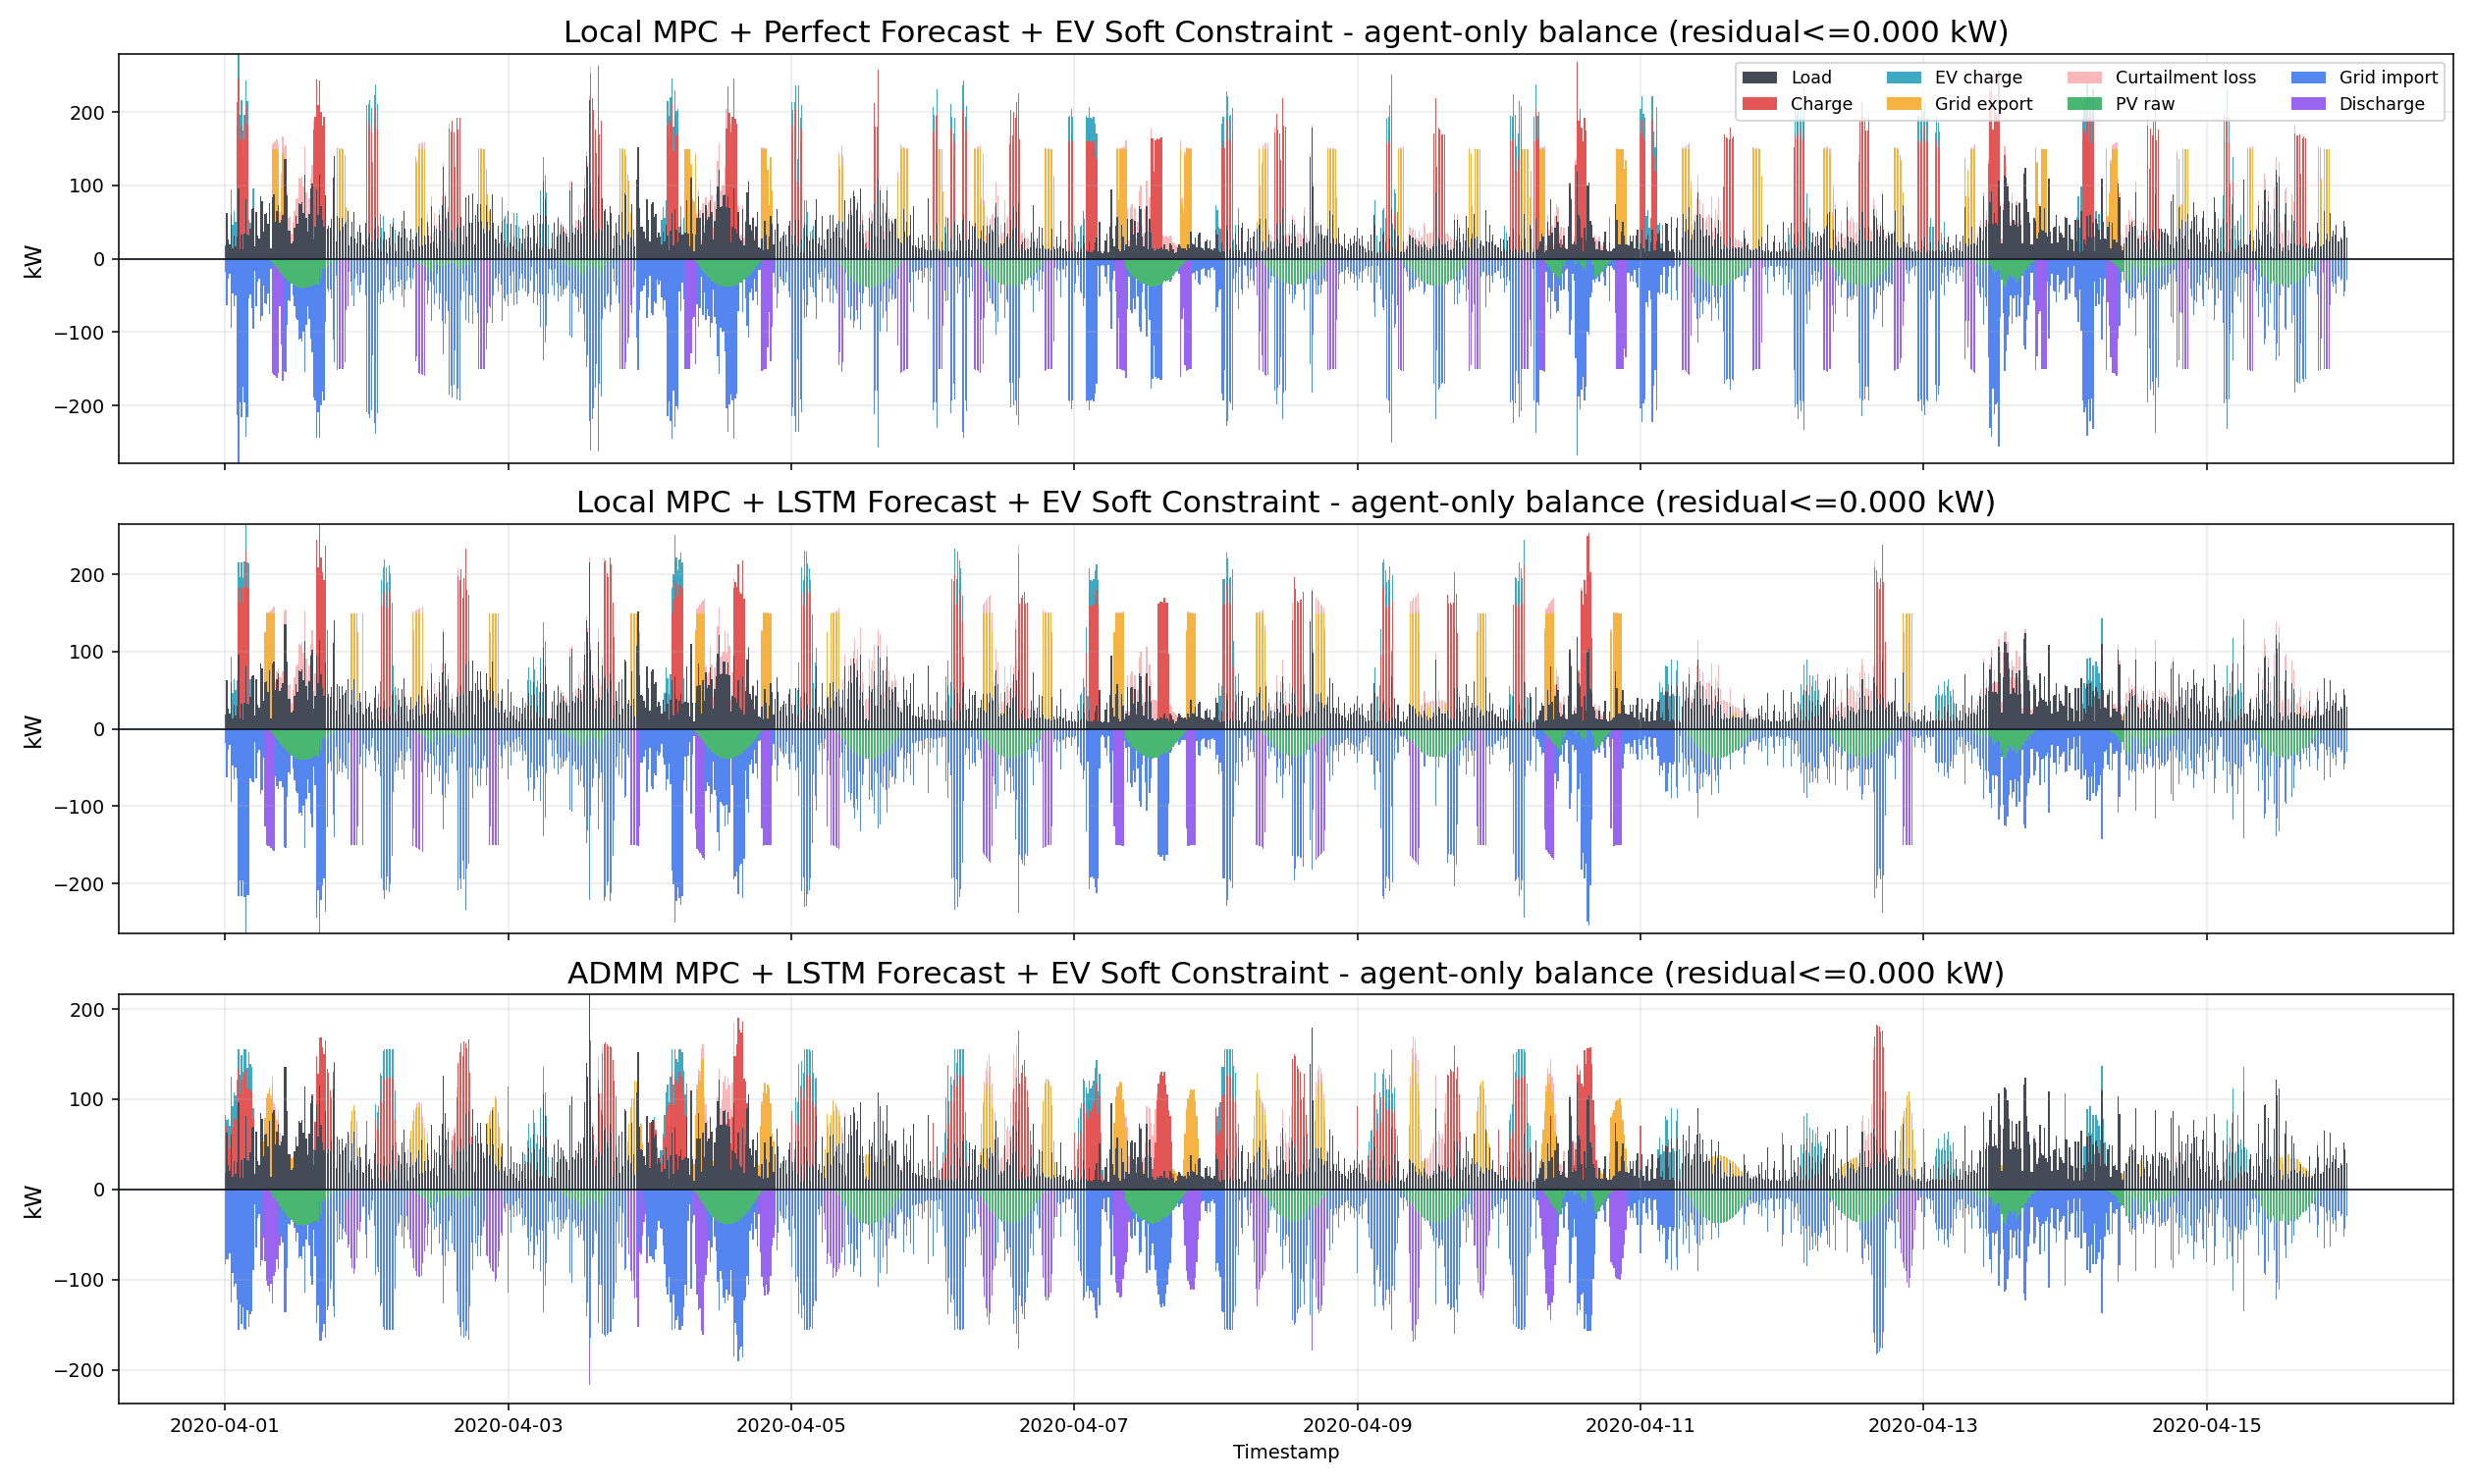

2. Price - soft


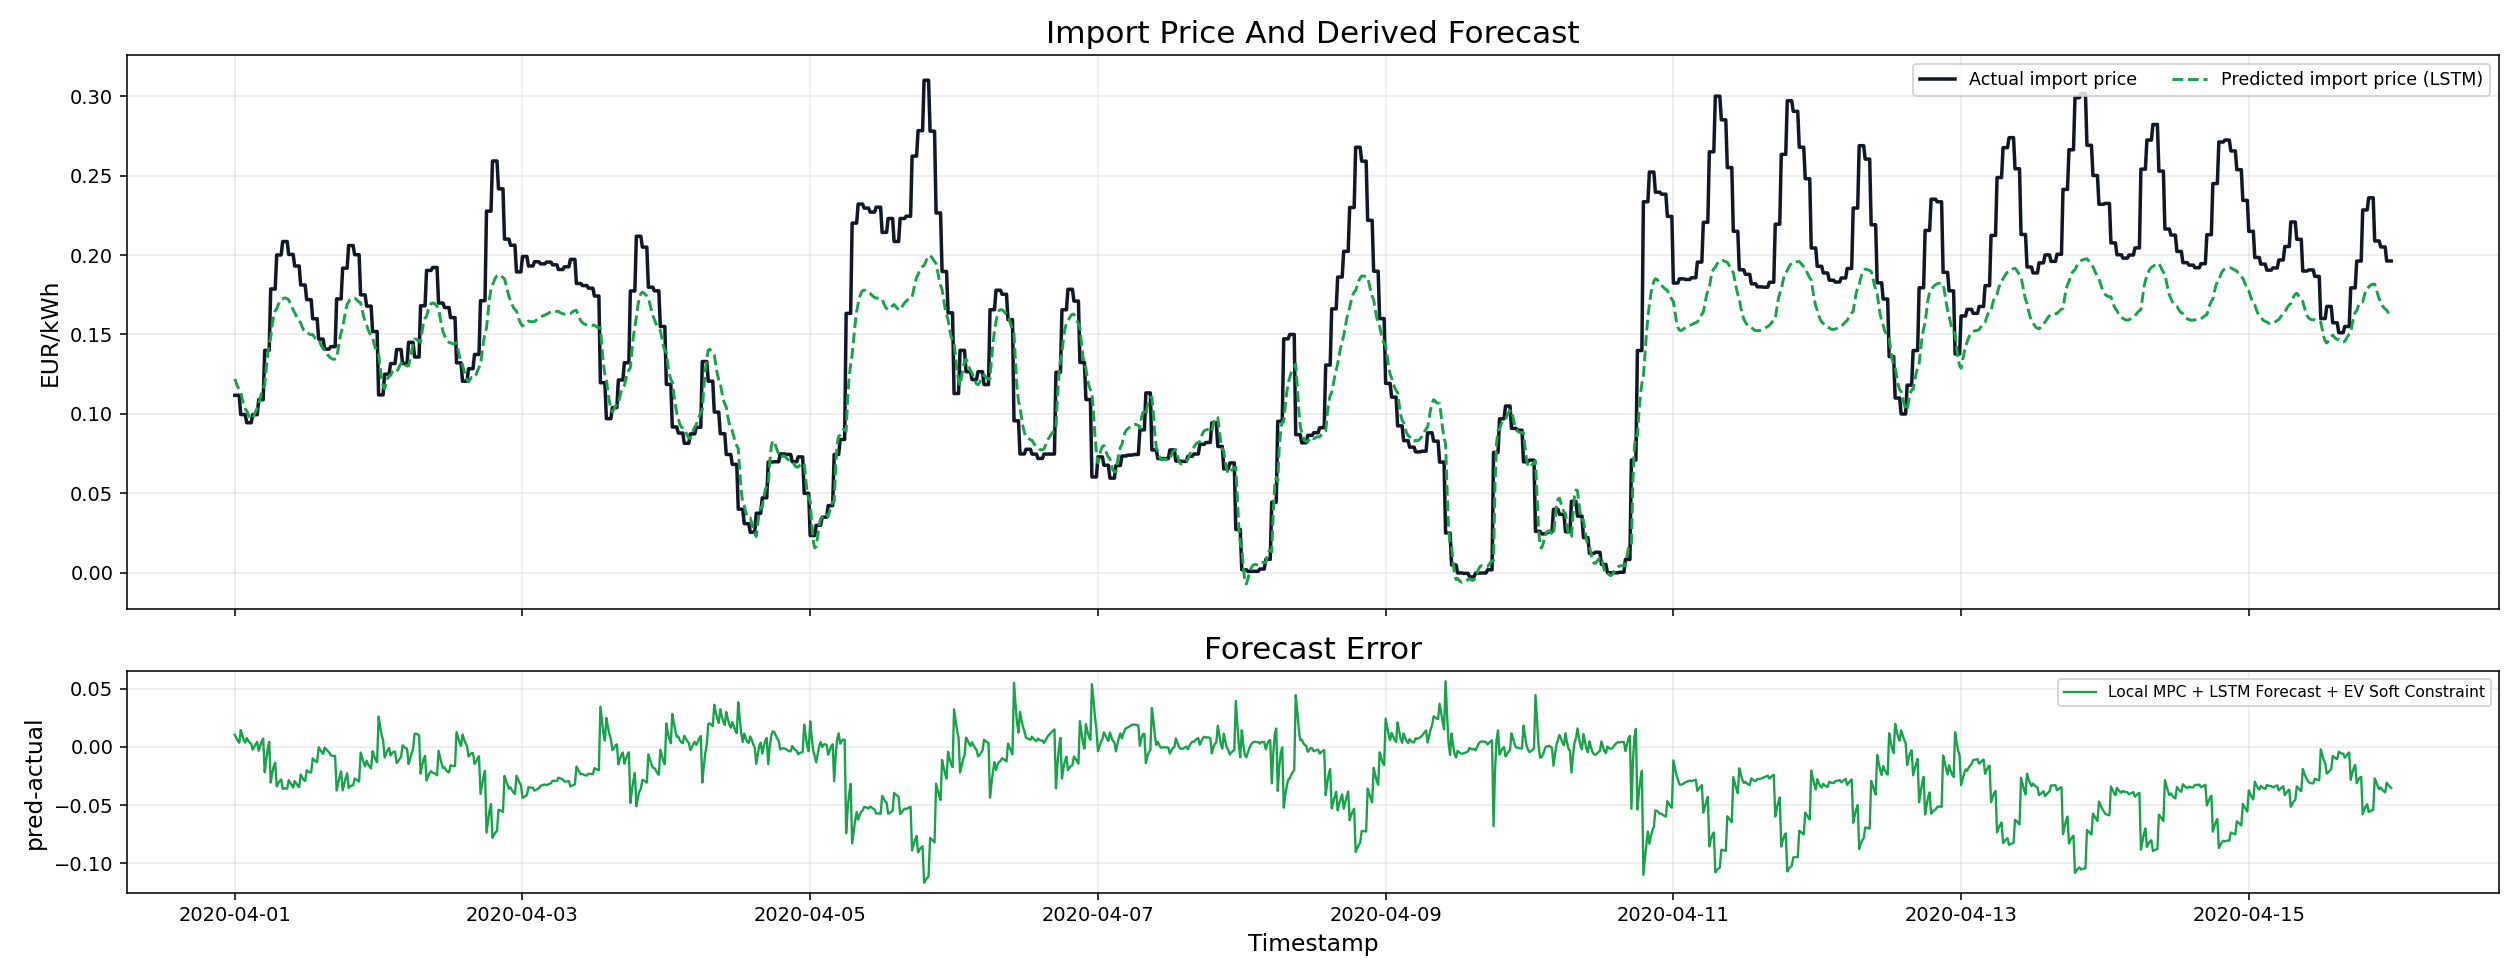

3. Battery power and SoC - soft


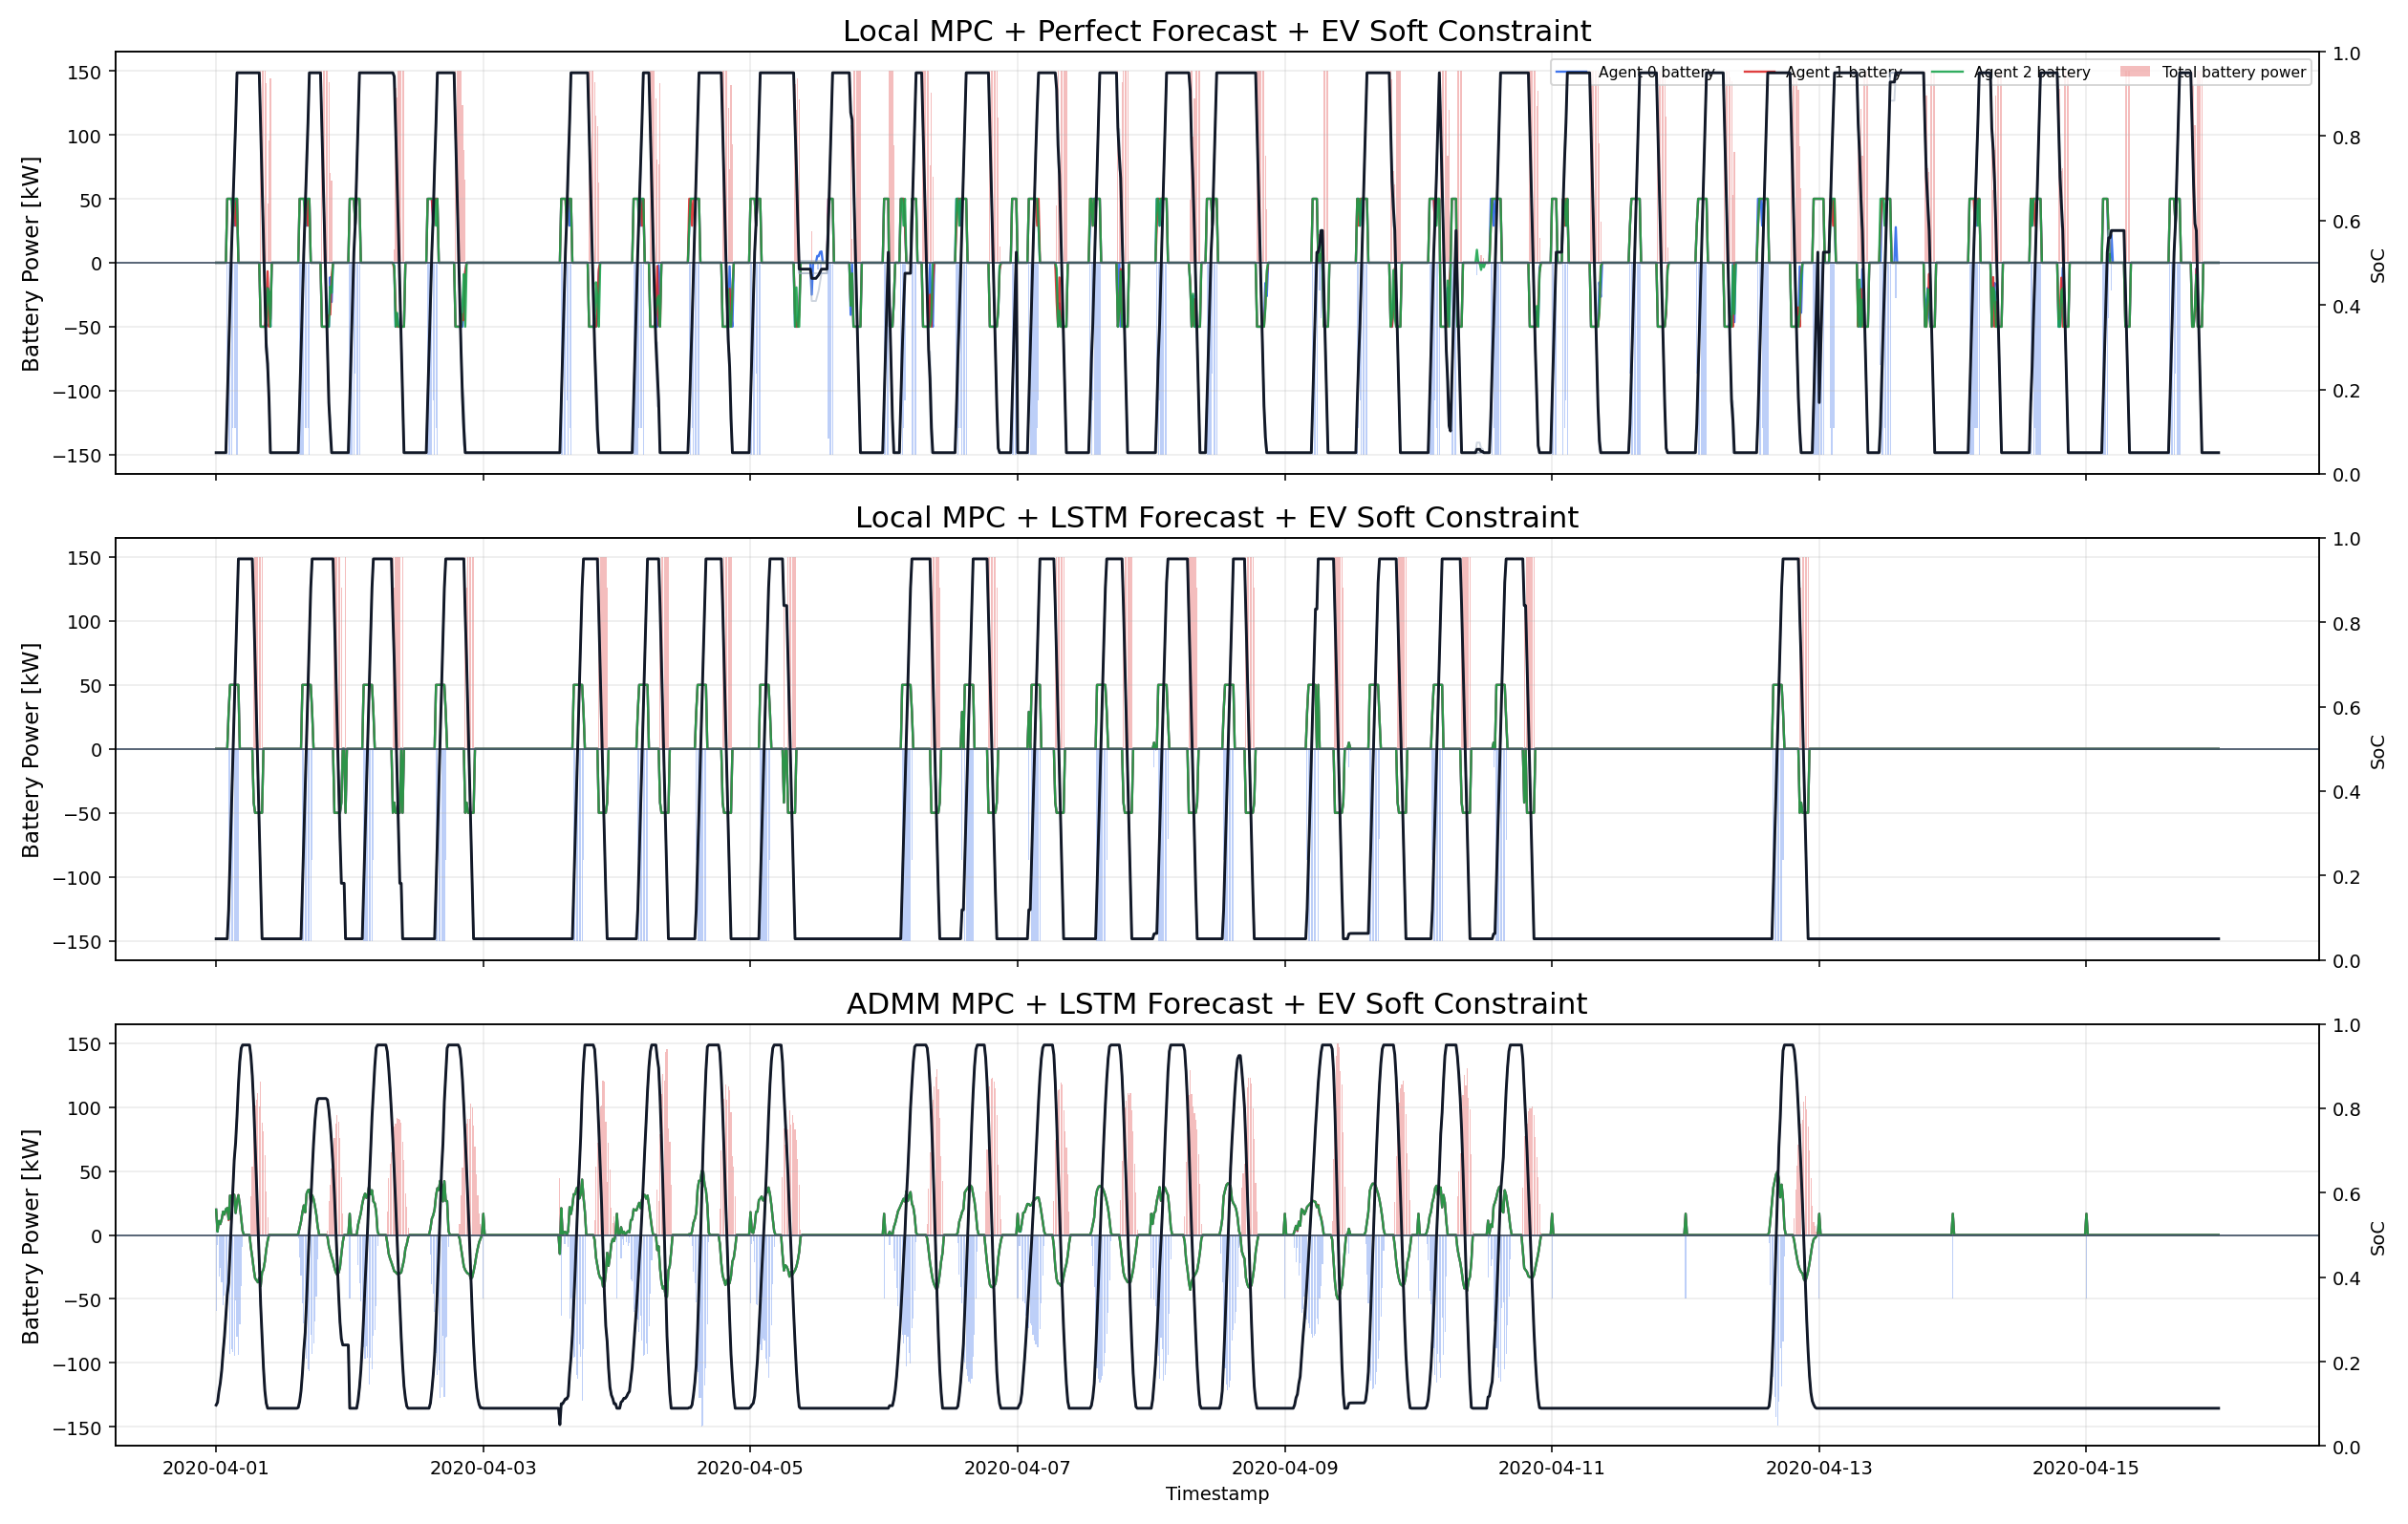

4. Voltage - soft


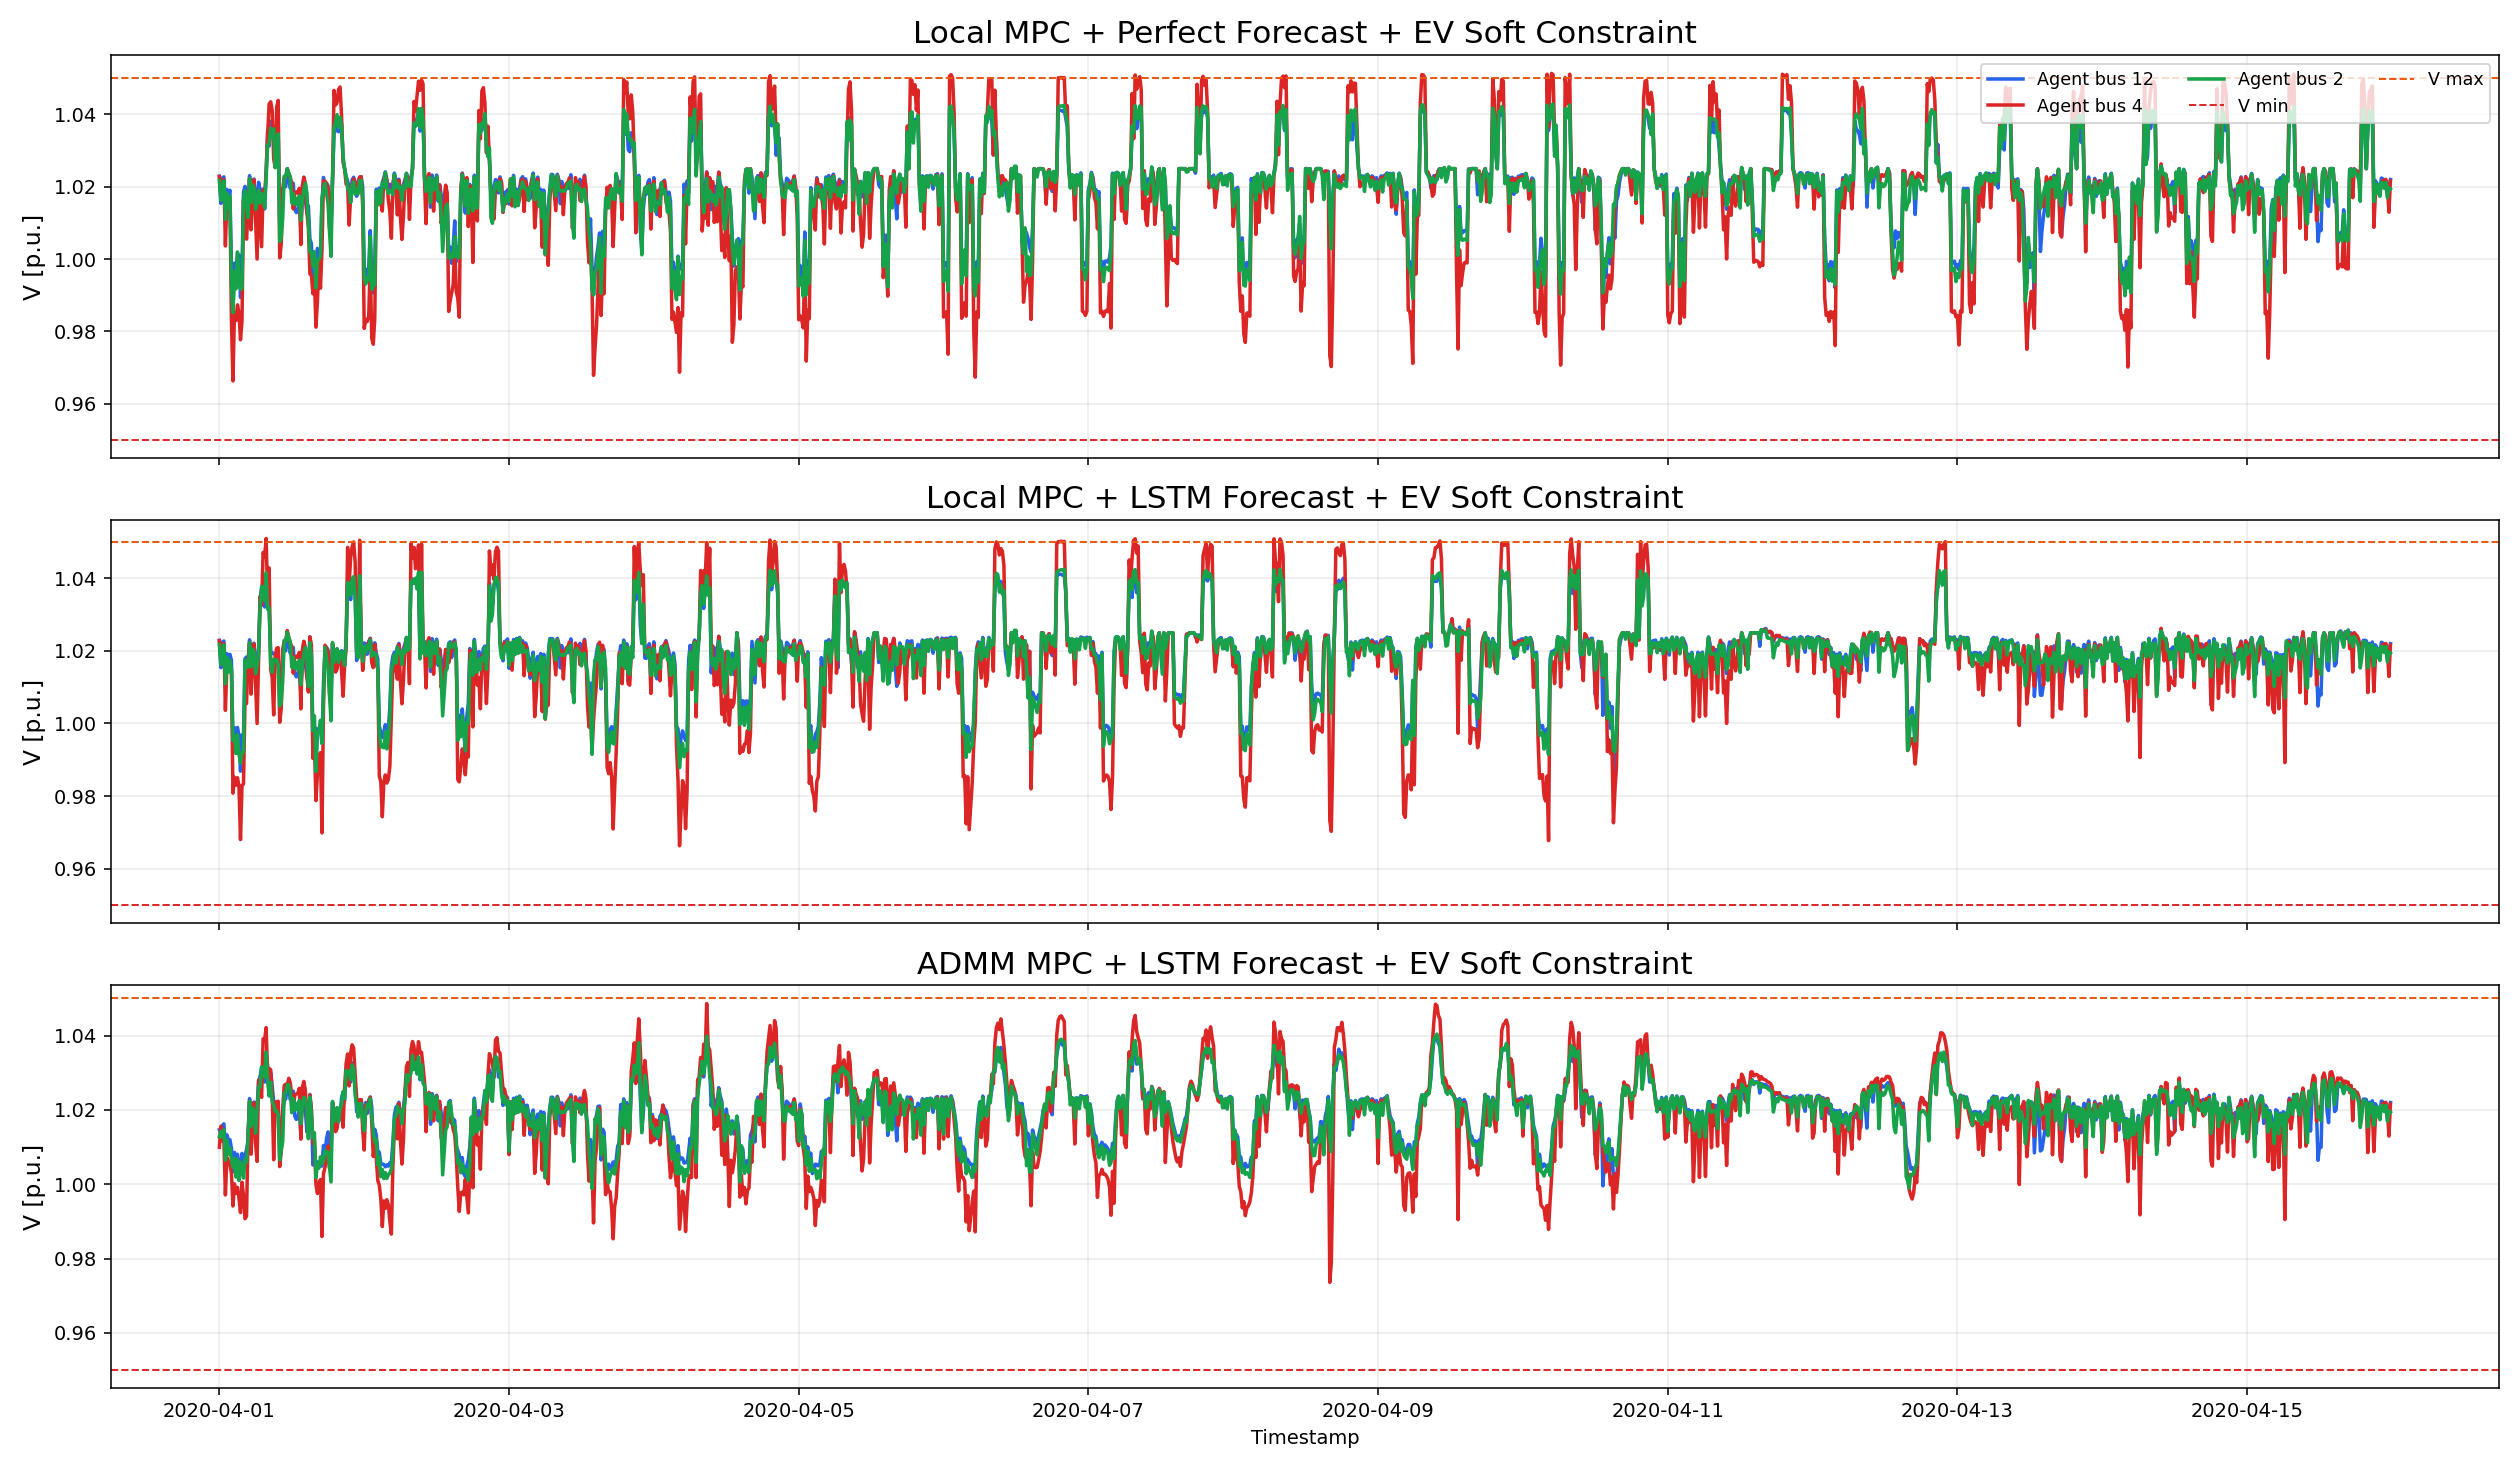

5. Net load - soft


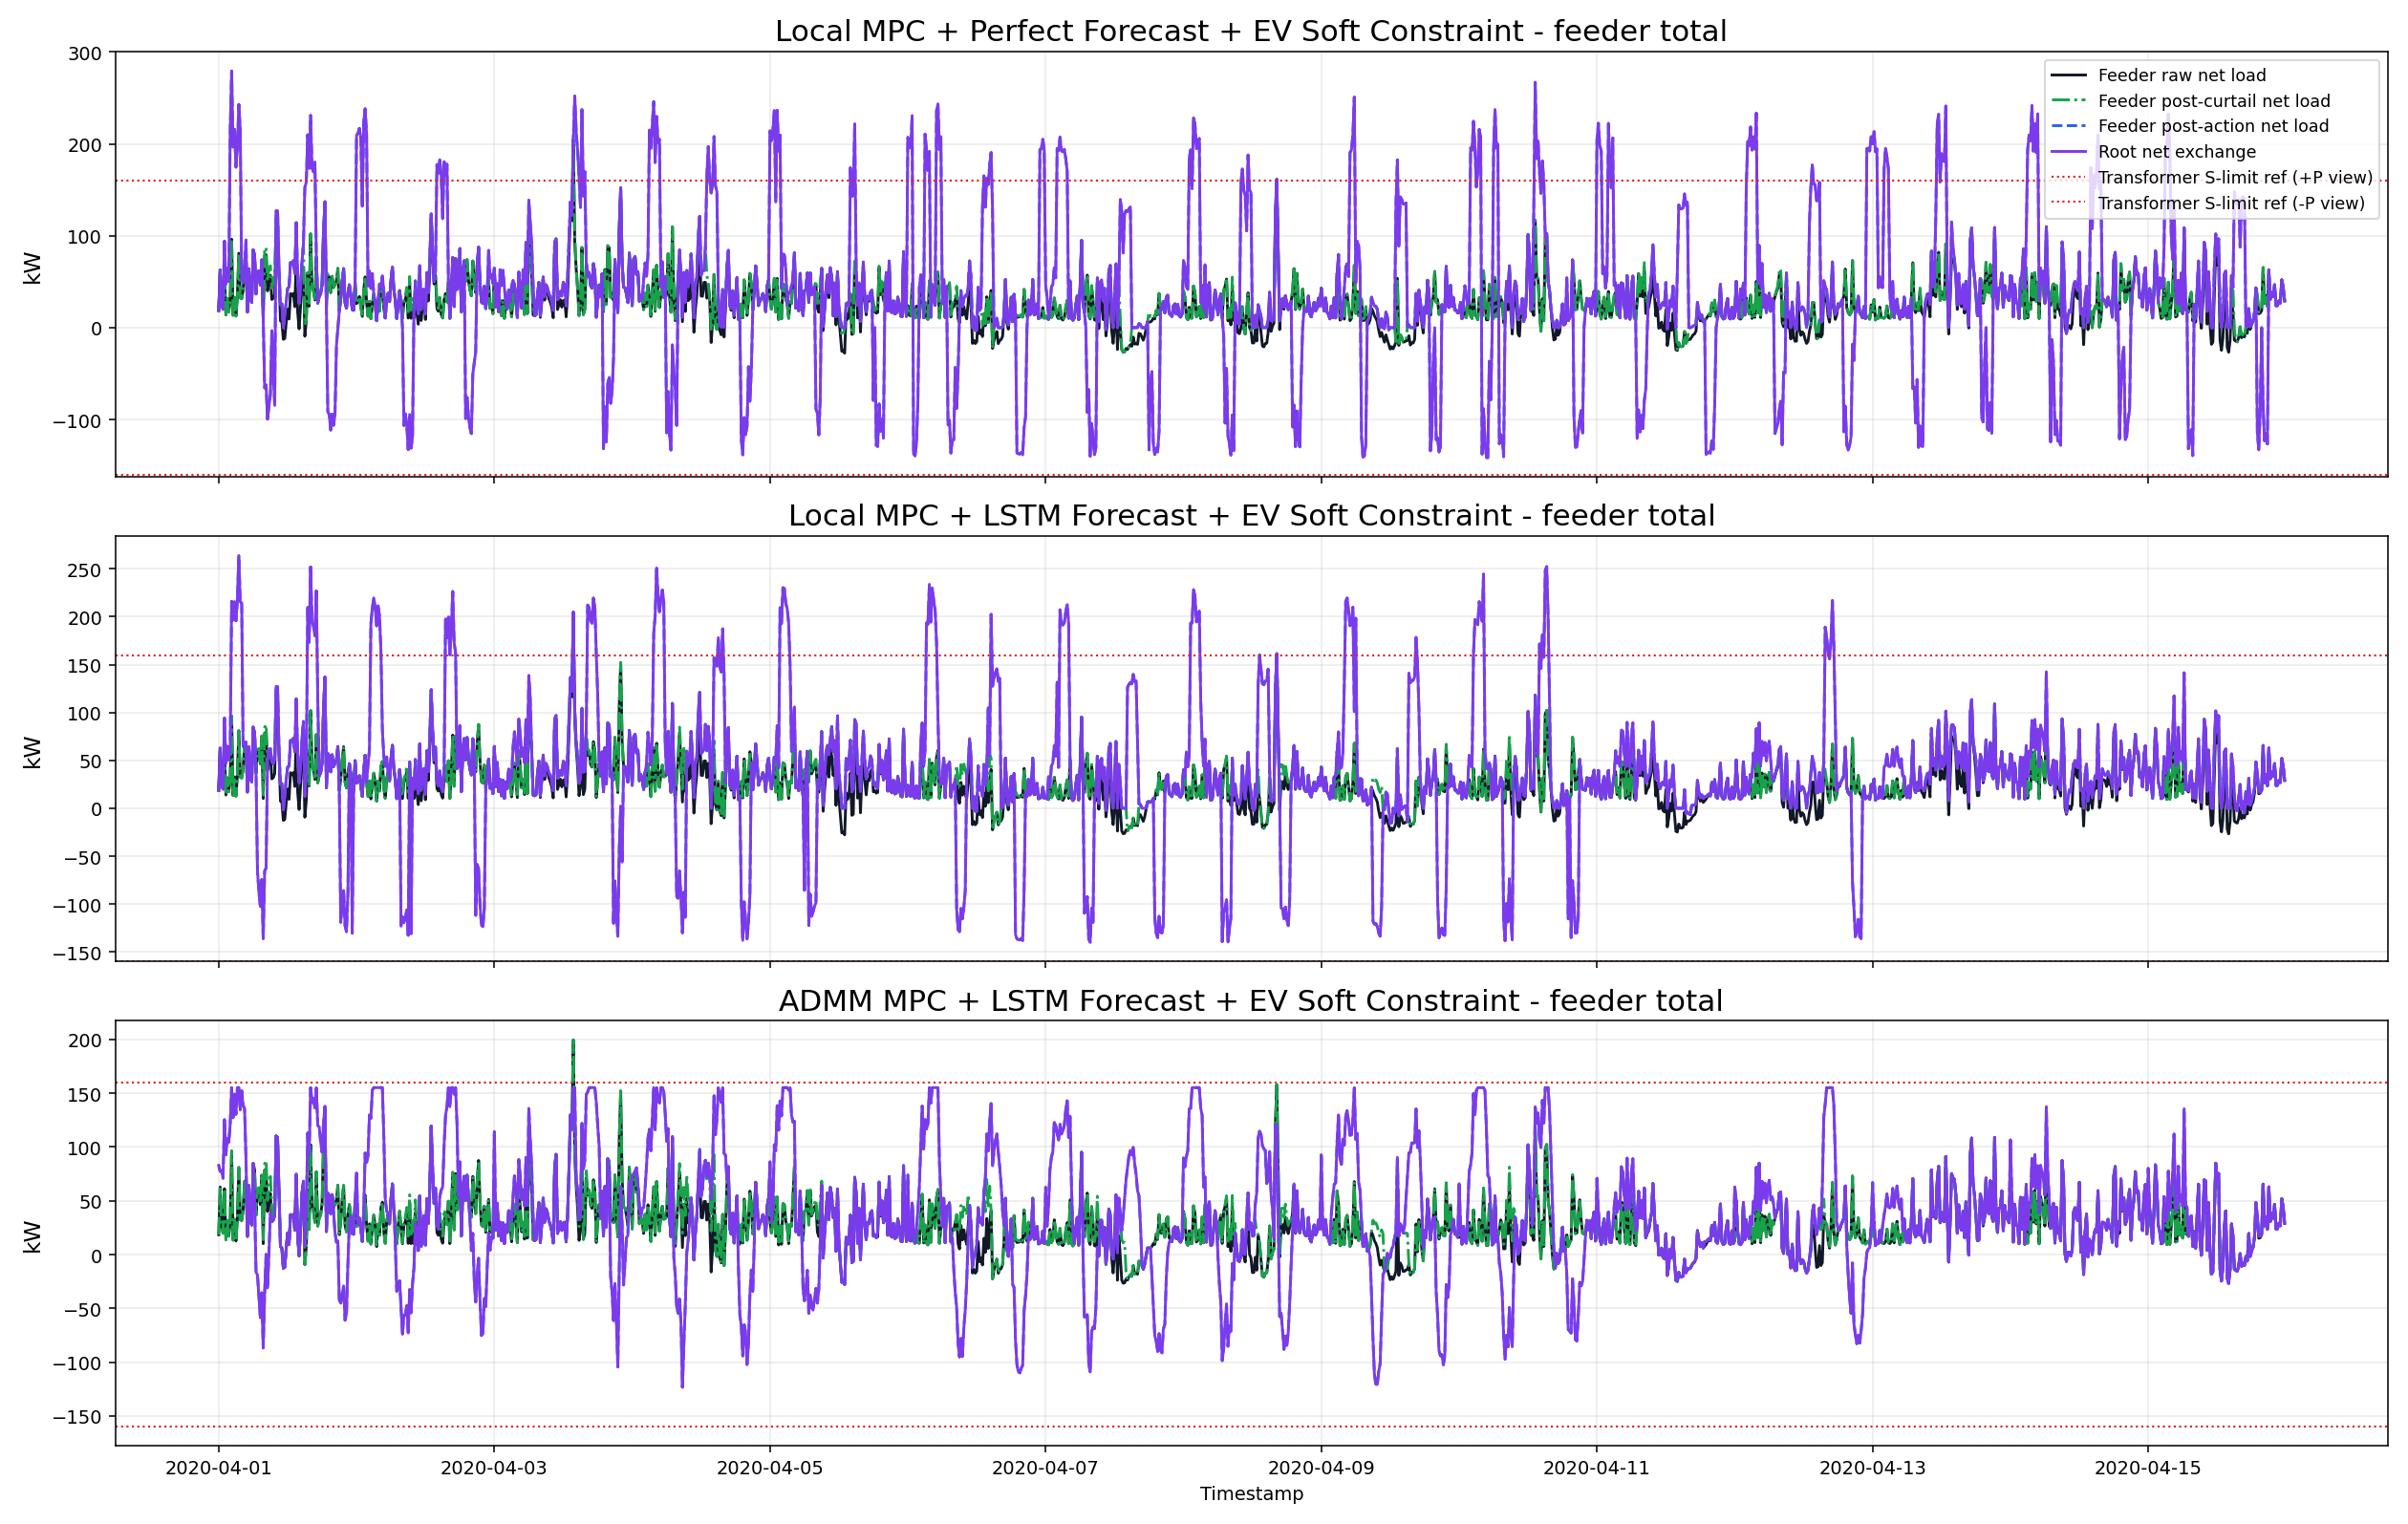

6. EV SOC - soft


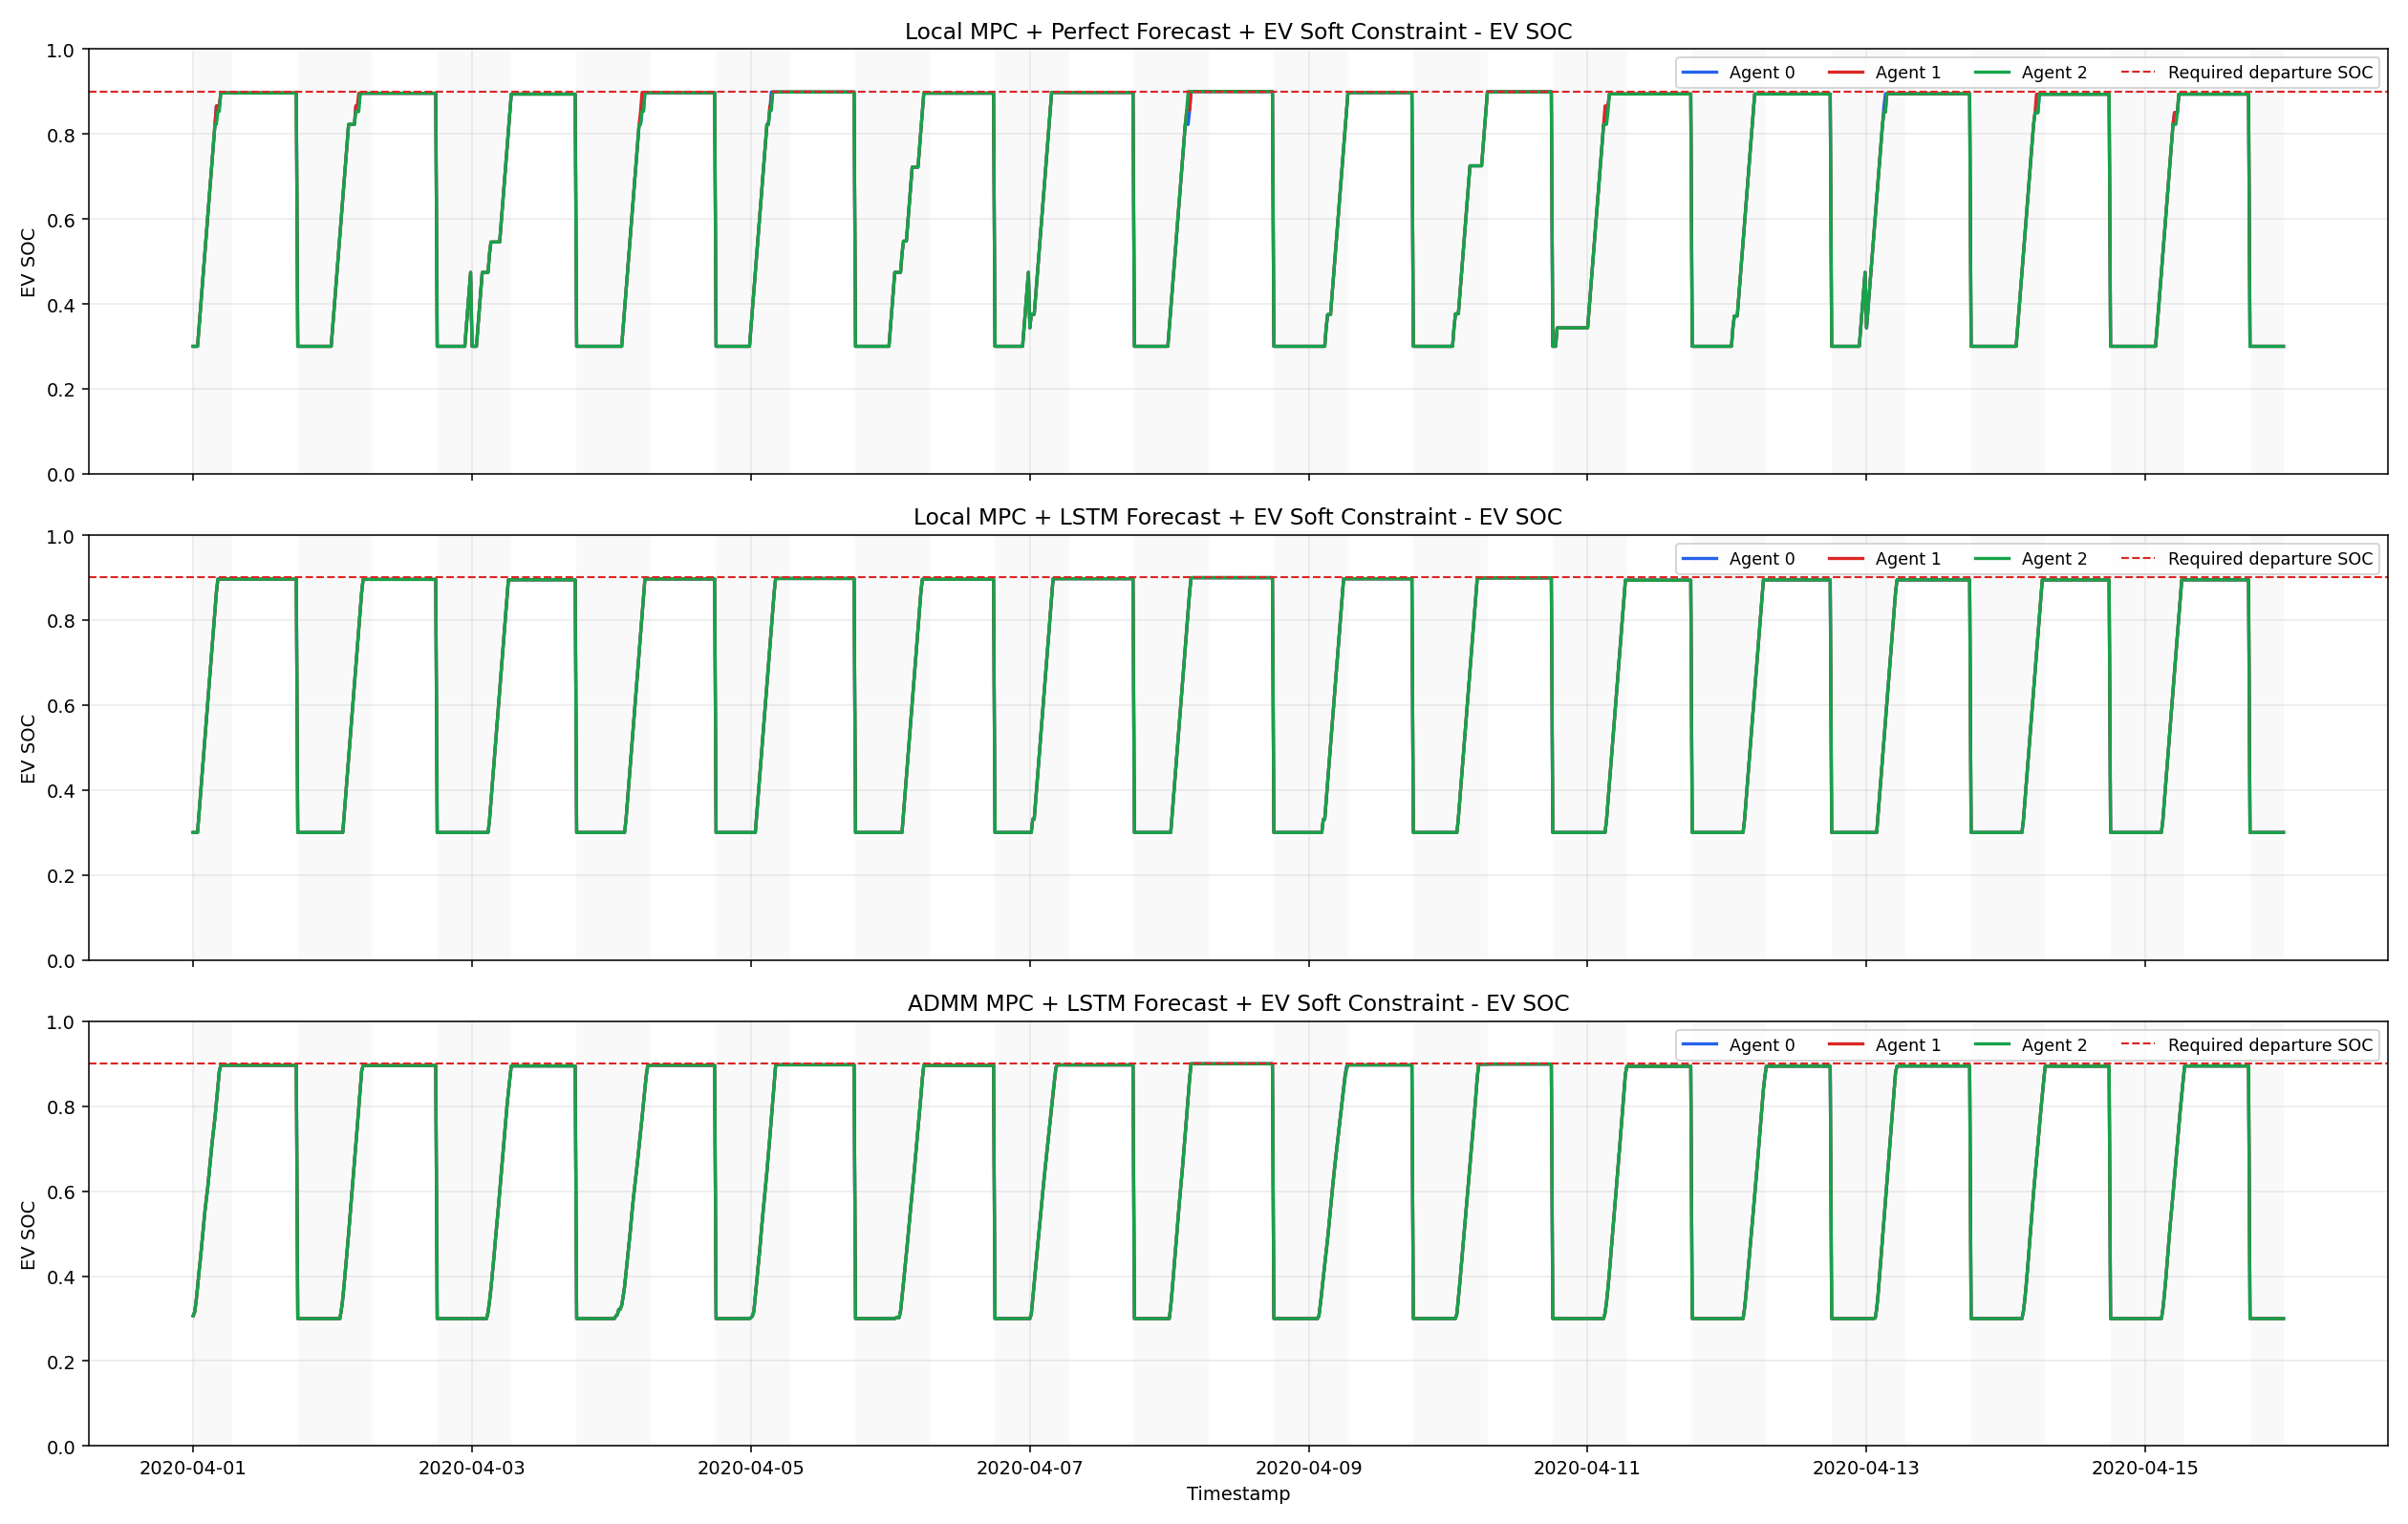

7. EV charging power - soft


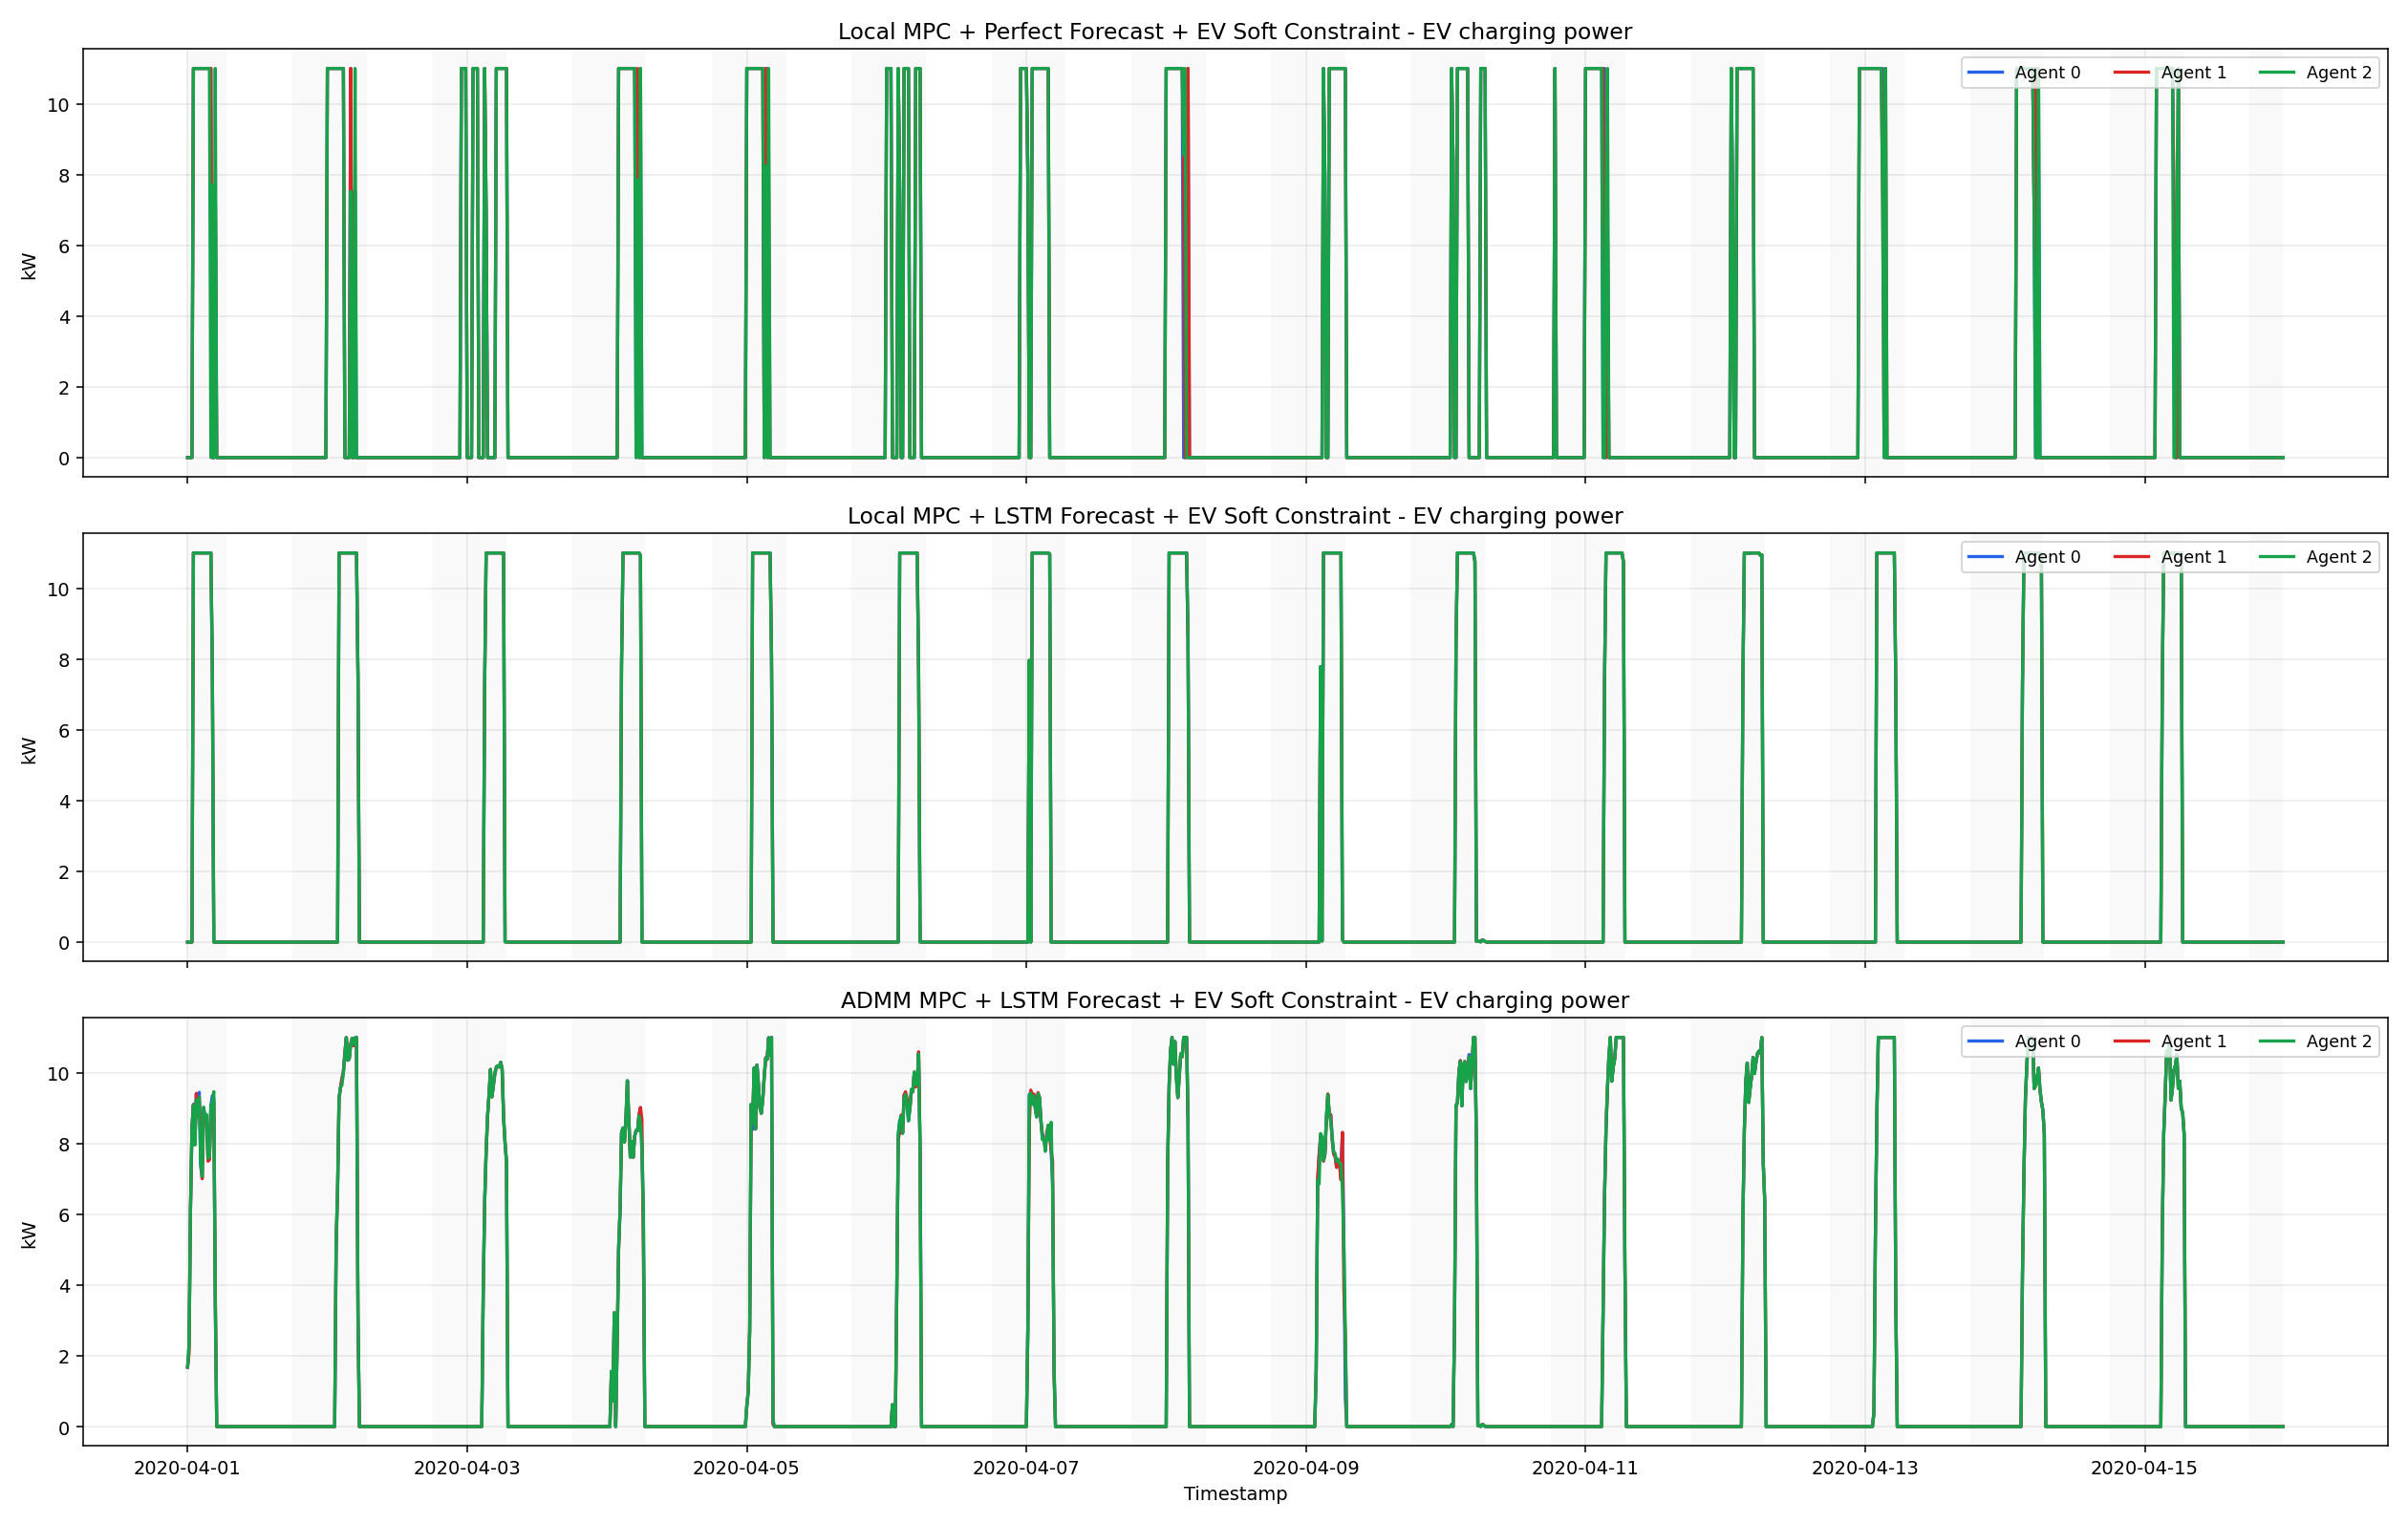

8. EV departure SOC requirement check - soft


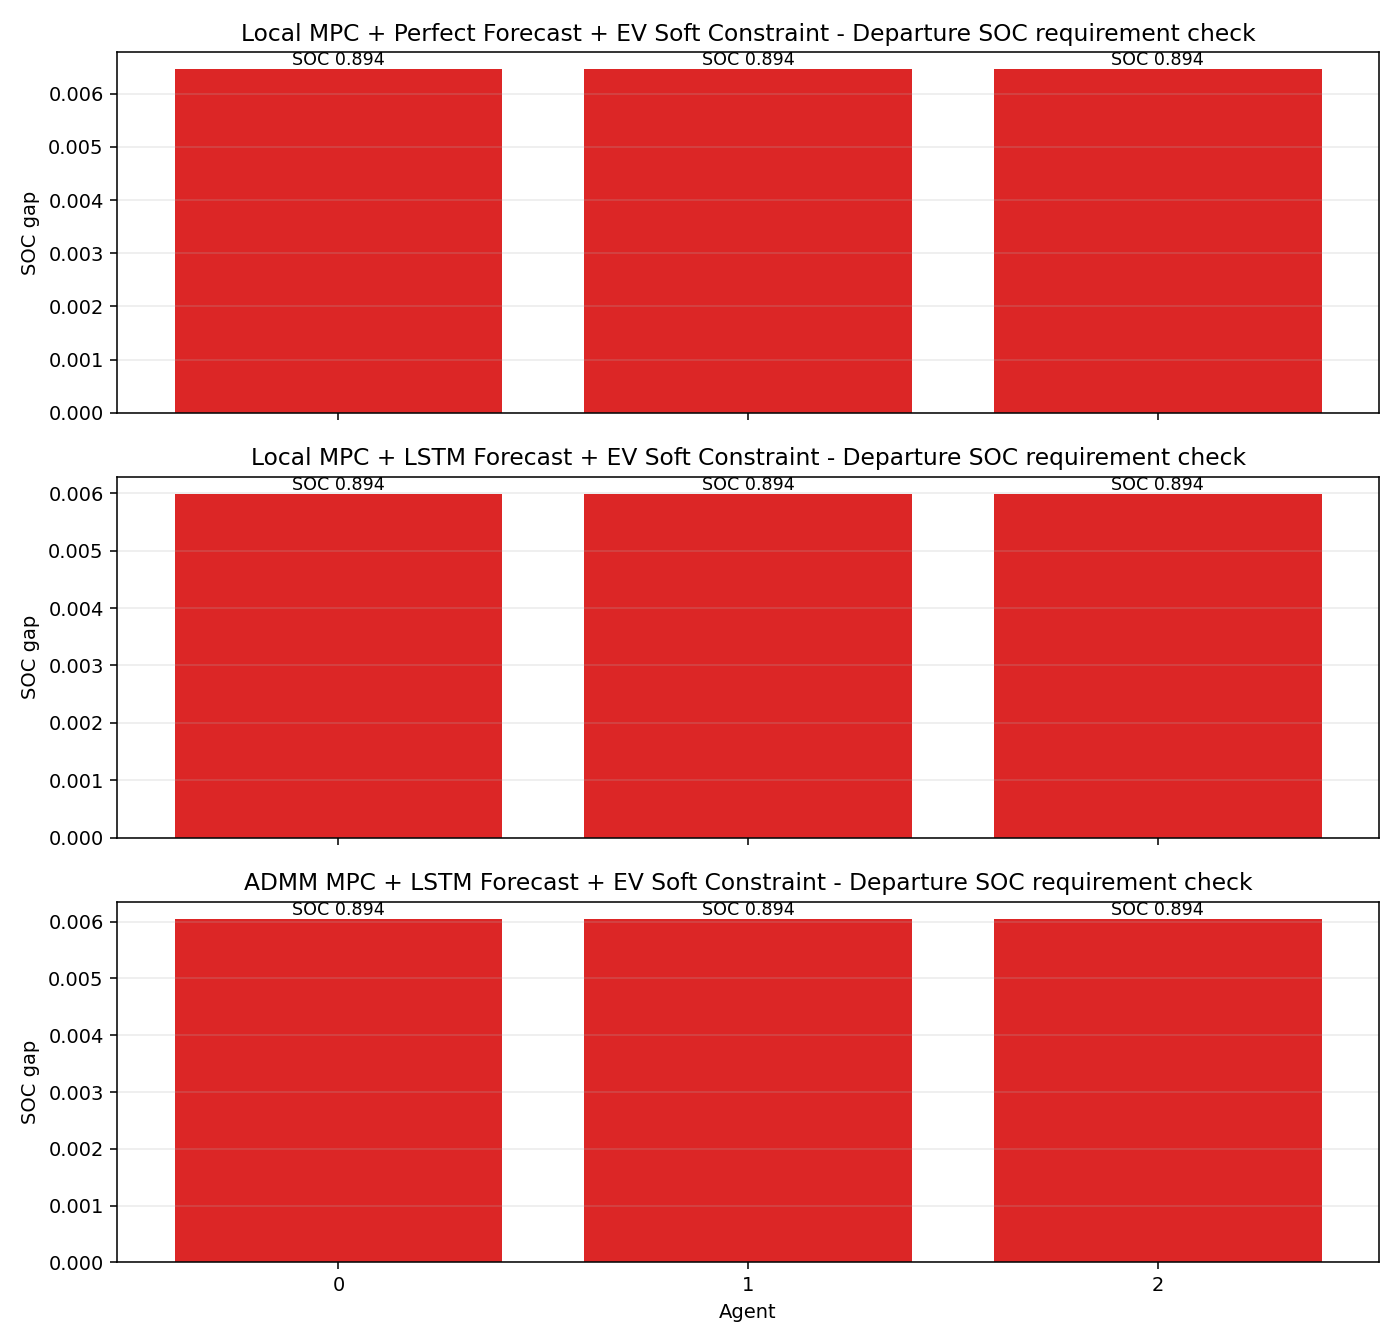

9. Total cost - soft


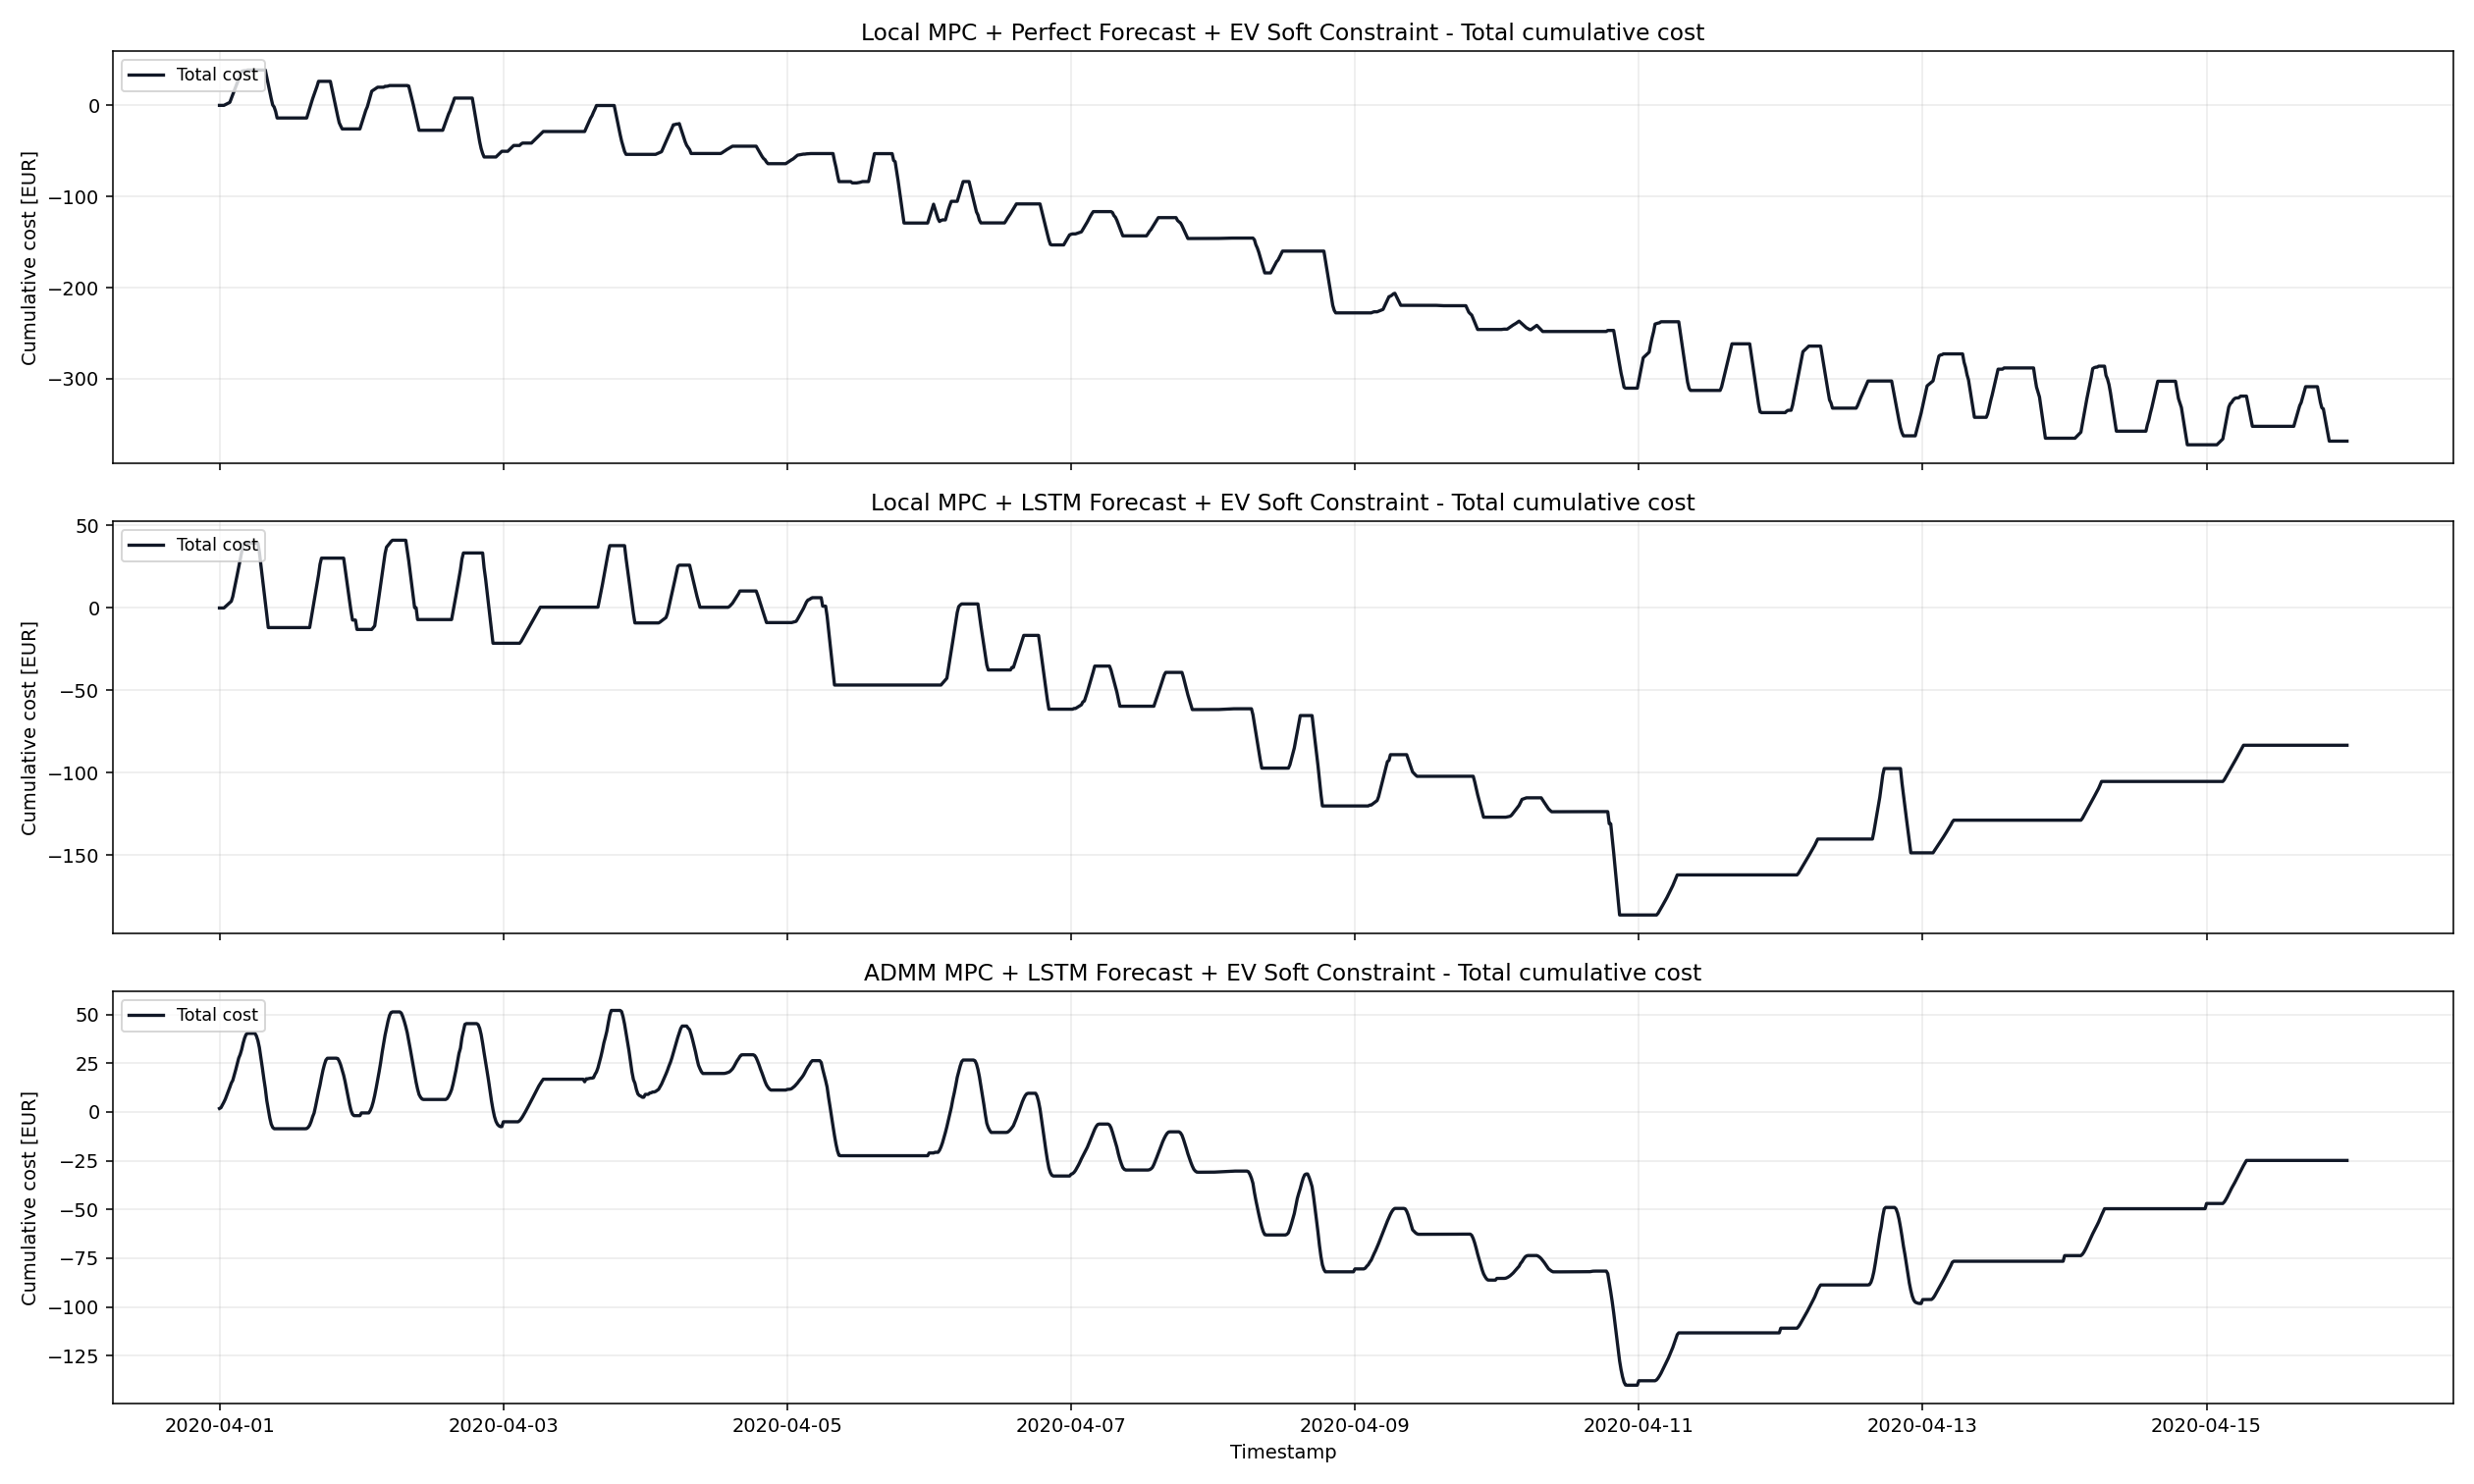

10. Cost components - soft


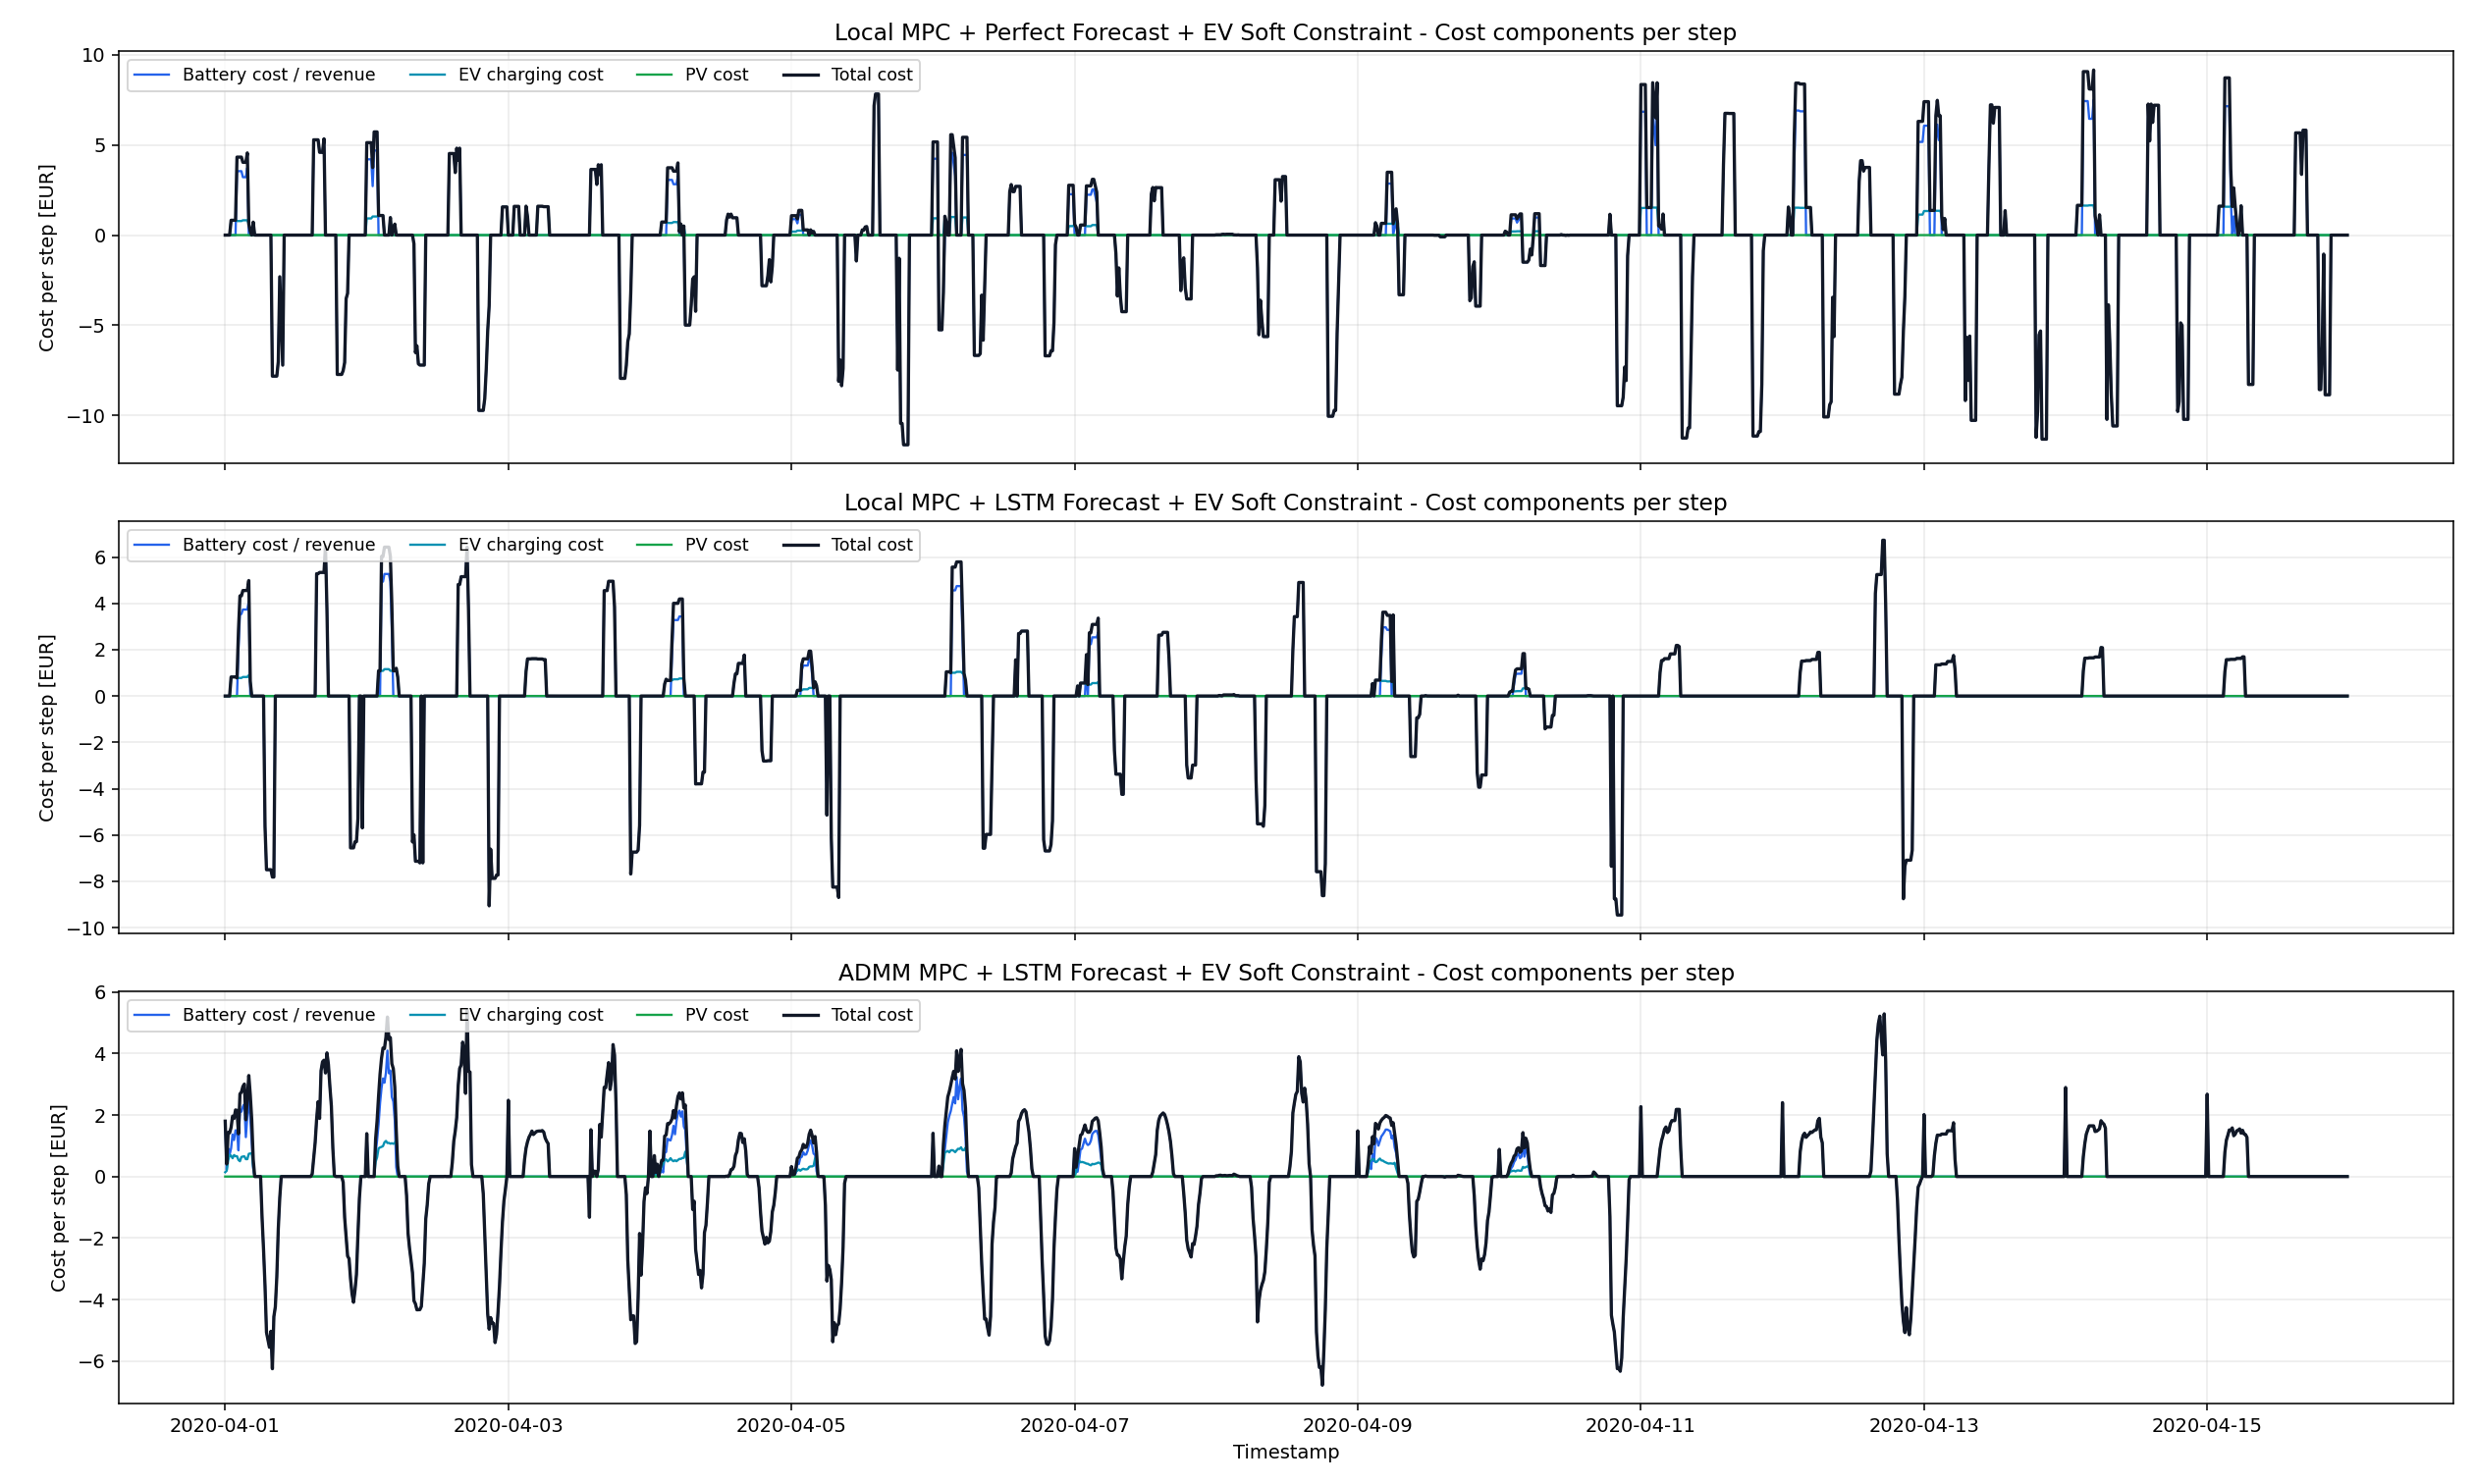

11. Cumulative cost components - soft


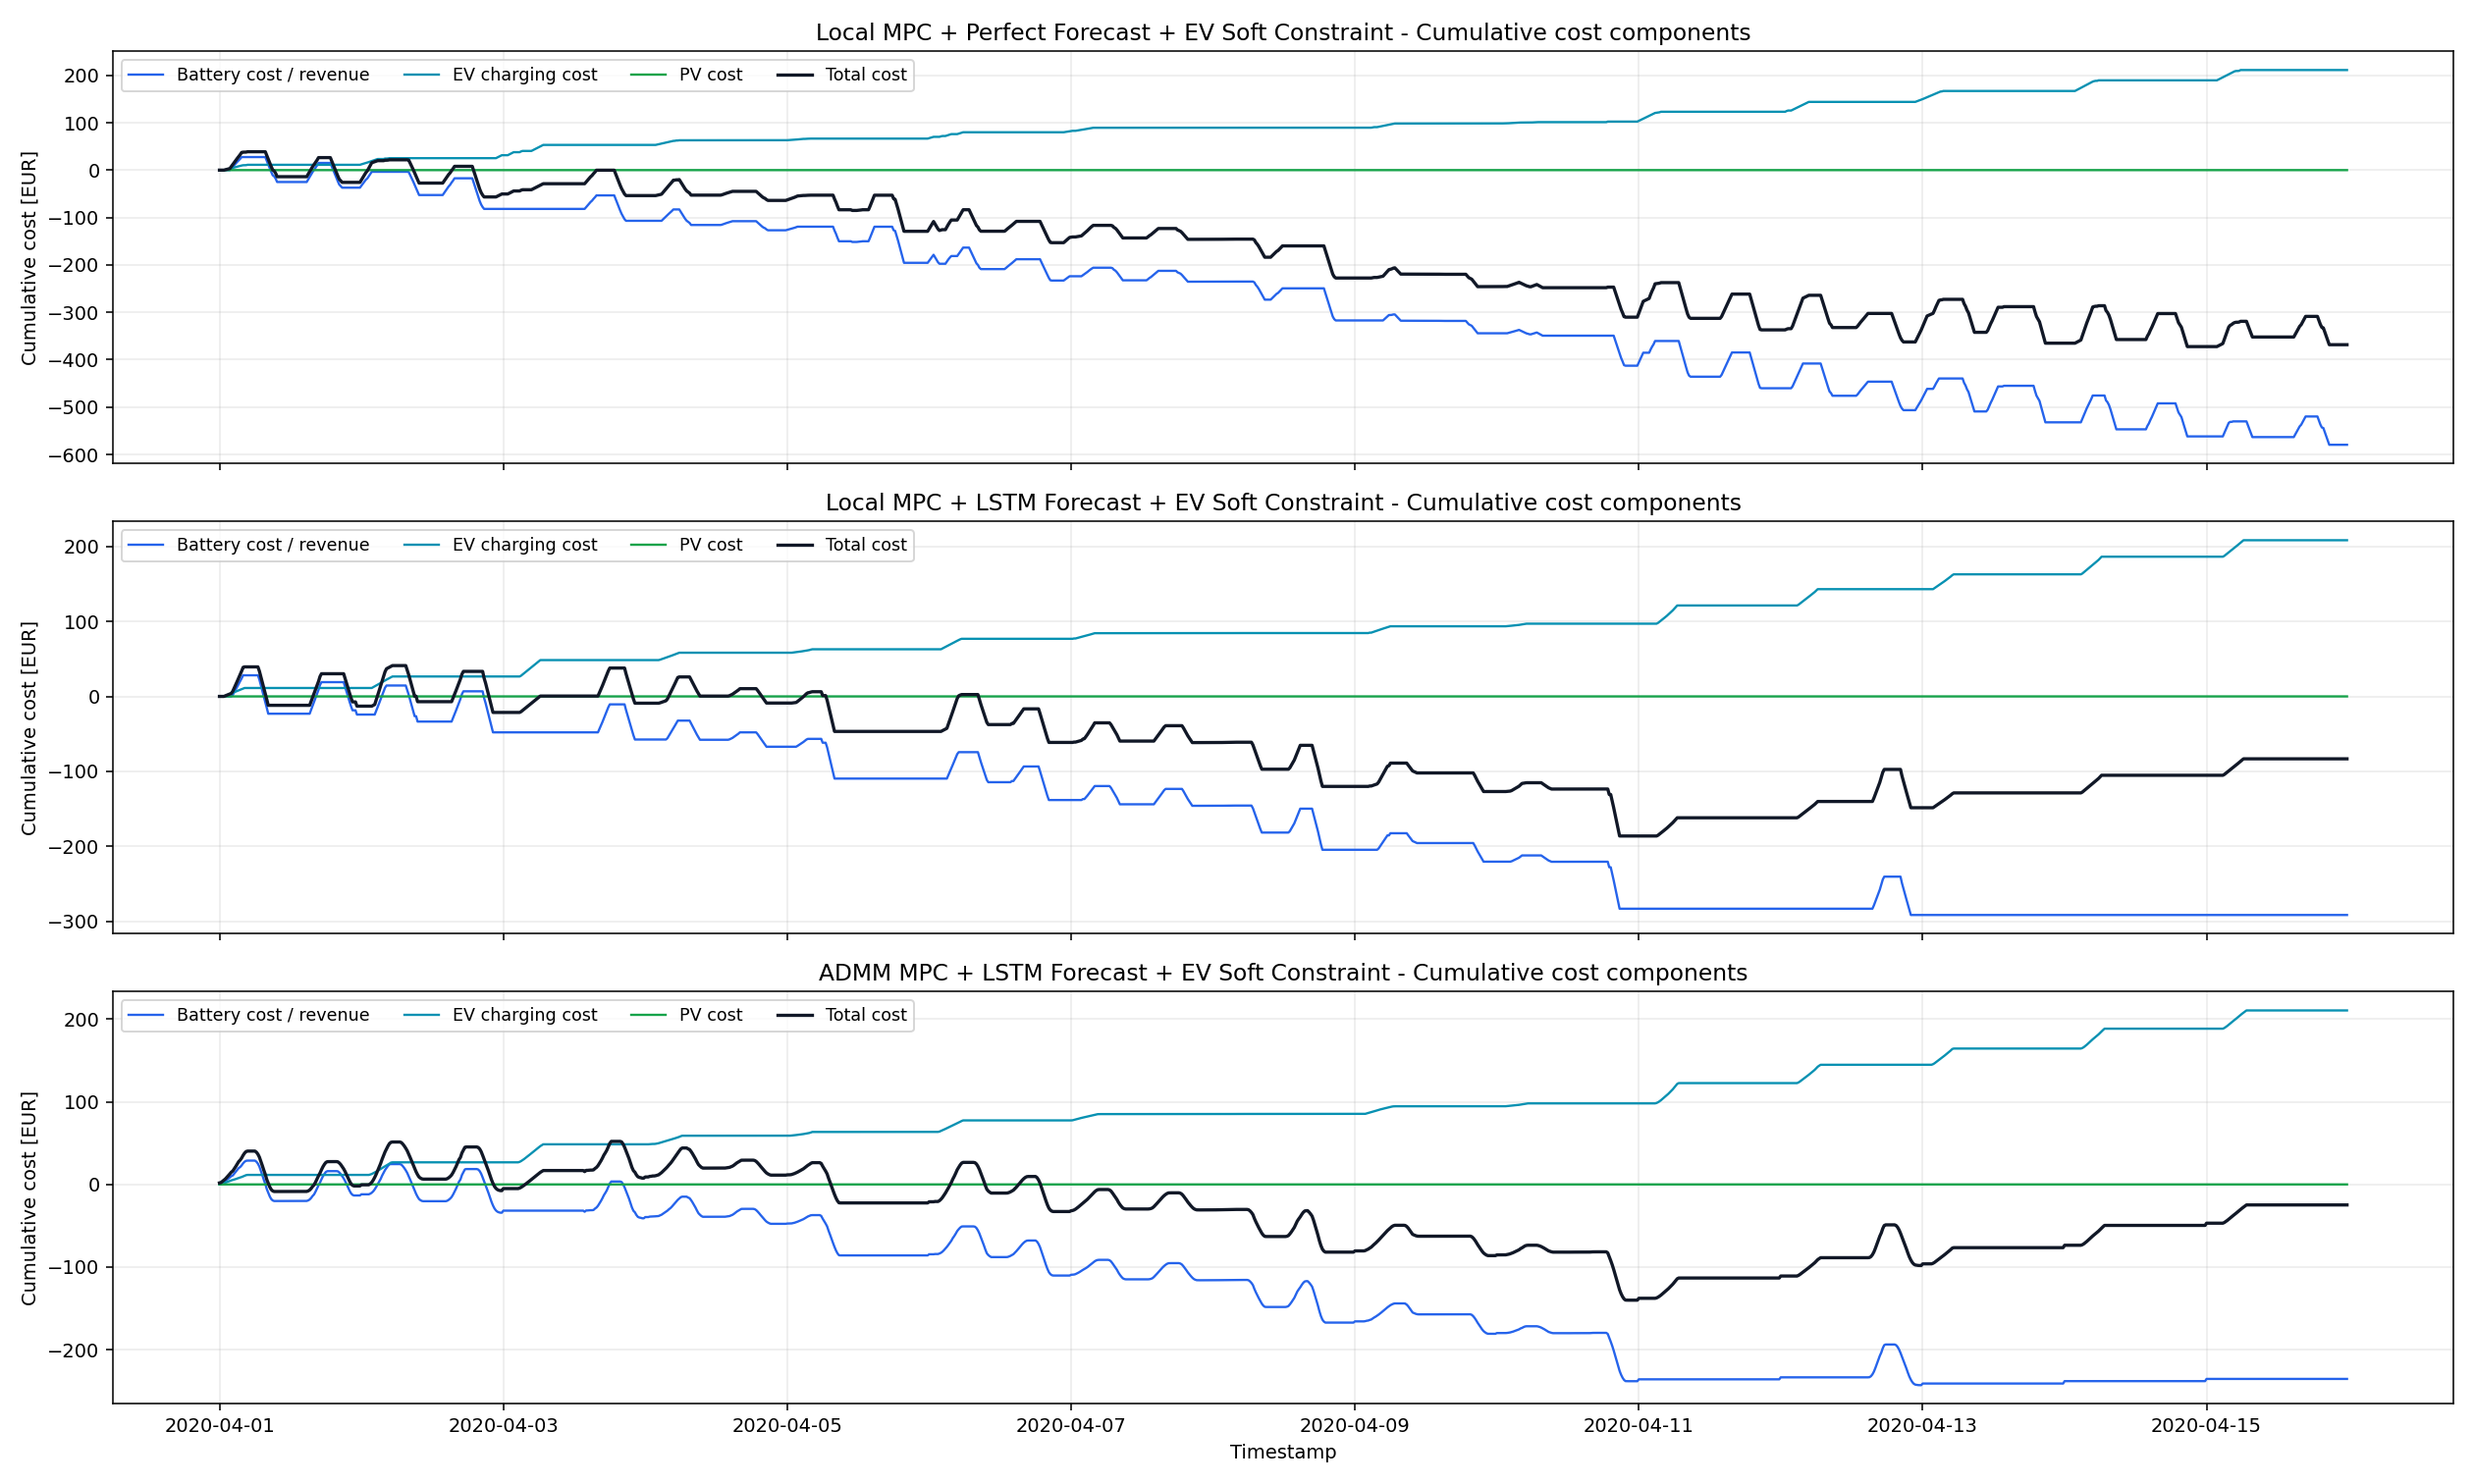

In [5]:
figures = plot_mpc_outputs(records, run_dir)
_plot_specs = [
    ("1. Power balance", "mpc_power_balance"),
    ("2. Price", "mpc_price"),
    ("3. Battery power and SoC", "mpc_battery_soc"),
    ("4. Voltage", "mpc_voltage"),
    ("5. Net load", "mpc_net_load"),
    ("6. EV SOC", "mpc_ev_soc"),
    ("7. EV charging power", "mpc_ev_charge_kw"),
    ("8. EV departure SOC requirement check", "mpc_ev_departure_check"),
    ("9. Total cost", "mpc_total_cost"),
    ("10. Cost components", "mpc_cost_components"),
    ("11. Cumulative cost components", "mpc_cumulative_cost_components"),
]
for title, name in _plot_specs:
    path = run_dir / "figures" / f"{name}.png"
    if path.exists():
        print(f"{title} - {cfg.env.ev_departure_constraint_mode}")
        display(Image(filename=str(path)))
        if name in figures:
            plt.close(figures[name])
    else:
        print(f"[missing] {title}: {path}")
